# 02-3. 피크 경보와 오류 분석

02-2 노트북의 최종 예측 모델로 **피크를 미리 알리는 경보**를 만들고, **예측과 경보가 어떤 조건에서 틀리는지** 분석합니다.
보고서 **제3장 「영향요인 및 오류분석」**의 근거 자료이며, 경보 설계는 제4장(현장 활용)으로 이어집니다.

| 예측 | 최종 모델 (02-2 노트북) | 경보의 쓰임 |
|---|---|---|
| 하루 앞 | 계획 기반 기준 곡선 | 전날: 내일 어느 시간대가 위험한지 보고 생산 일정 조정 |
| 1시간 앞 | 선형 회귀 + Chronos-2 평균 | 당일: 곧 피크가 올 때 설비 가동 시점 조정 |

## 0. 준비

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path("../outputs/figures"); TAB_DIR = Path("../outputs/tables"); PRED_DIR = Path("../outputs/predictions")
def save_fig(fig, name): fig.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")
def save_table(df, name): df.to_csv(TAB_DIR / f"{name}.csv", encoding="utf-8-sig")

slots = pd.read_csv("../data/processed/slots_15min.csv", encoding="utf-8-sig", parse_dates=["ts", "date"], index_col="ts")
slots["칸번호"] = (slots["시각"] * 4).astype(int)
slots["하루종류코드"] = slots["하루종류"].map({"평일가동": 0, "토요일": 1, "휴일": 2})
CURVE_KEYS = ["하루종류코드", "전날가동", "칸번호"]
TEST_STARTS = pd.to_datetime(["2021-08-09", "2021-08-16", "2021-08-23", "2021-08-30", "2021-09-06"])
TEST_ENDS = list(TEST_STARTS[1:]) + [pd.Timestamp("2021-09-15")]
FIRST_TEST = TEST_STARTS[0]

day = pd.read_csv(PRED_DIR / "final_day_ahead.csv", encoding="utf-8-sig", parse_dates=["ts", "date"], index_col="ts")
day = day.join(slots[["하루종류", "하루종류코드", "전날가동", "칸번호", "기온", "일생산량"]])
hour = pd.read_csv(PRED_DIR / "pred_hour_ahead.csv", encoding="utf-8-sig", parse_dates=["발행시각", "대상시각"])
hour = hour.join(slots[["하루종류", "전날가동", "기온"]], on="대상시각")
hour["date"] = hour["대상시각"].dt.normalize()
FINAL_H = "선형 회귀 + Chronos-2 평균 (최종)"
print("하루 앞:", day.shape, "| 1시간 앞:", hour.shape)

하루 앞: (3552, 10) | 1시간 앞: (3480, 18)


## 1. 피크 기준 정하기 — 요금 제도와 현장 관리 방식에서 출발

데이터 분포(상위 몇 %)만 보고 기준을 정하면 '왜 그 값인가'를 설명하기 어렵습니다. 그래서 **실제 요금 제도와 공장의 피크 관리 방식**을 조사해 기준을 정했습니다(README의 참고문헌).

- **한전 기본요금**: 기본요금에 쓰이는 전력(요금적용전력)은 *직전 12개월 중 12·1·2·7·8·9월과 당월의 15분 최대수요전력 가운데 가장 큰 값*입니다(한전 기본공급약관 제68조). 이 데이터의 7~9월은 모두 요금에 반영되는 달이므로, **지금까지의 최대치를 넘는 15분 한 번이 최대 12개월 동안 기본요금을 올립니다.**
- **최대전력 관리장치**: 공장은 보통 **목표전력**을 정해 두고, 넘을 우려가 있으면 **1단계 경보(주의) → 2단계(부하 차단)** 순으로 대응합니다. 몇 %에서 경보할지는 공장마다 정하며, 공통 표준은 확인하지 못했습니다.

그래서 이 분석의 기준은 다음과 같습니다.
- **목표전력** = 학습 기간(7/1~8/8)의 최대수요전력. 시험 기간이 시작되기 전에 이미 알 수 있는 값입니다.
- **1단계 '주의'** = 목표전력의 85% → **주 평가 기준**
- **2단계 '경고'** = 목표전력의 90%
- 85%·90%는 우리가 정한 설계값이므로, 다른 비율의 결과도 함께 봅니다.

In [2]:
train_obs = slots[(slots.index < FIRST_TEST) & slots["정답사용"]]
TARGET = train_obs["전력"].max()
L1, L2 = 0.85 * TARGET, 0.90 * TARGET
test_obs = slots[(slots.index >= FIRST_TEST) & slots["정답사용"]]
print(f"목표전력 = {TARGET:.0f} (학습 기간 최대, {train_obs['전력'].idxmax():%m/%d %H:%M})")
print(f"시험 기간 최대 = {test_obs['전력'].max():.0f} ({test_obs['전력'].idxmax():%m/%d %H:%M})")

def events(series, thr):
    over = series >= thr
    return (over & ~over.shift(1, fill_value=False)).sum()

rows = []
for ratio in [0.80, 0.85, 0.90, 0.95, 1.00]:
    thr = ratio * TARGET
    over = test_obs["전력"] >= thr
    rows.append({"기준": f"목표전력의 {ratio:.0%}", "기준값": round(thr), "넘은 15분 칸": int(over.sum()),
                 "피크 사건 수 (연속 칸은 1회)": int(events(test_obs["전력"], thr)), "넘은 날": test_obs[over]["date"].nunique()})
levels = pd.DataFrame(rows).set_index("기준")
save_table(levels, "t18_피크기준_사례수")
levels

목표전력 = 222 (학습 기간 최대, 07/19 11:15)
시험 기간 최대 = 218 (08/11 08:30)


,기준값,넘은 15분 칸,피크 사건 수 (연속 칸은 1회),넘은 날
기준,,,,
목표전력의 80%,178,346,141,26
목표전력의 85%,189,116,68,20
목표전력의 90%,200,18,12,6
목표전력의 95%,211,3,2,2
목표전력의 100%,222,0,0,0


**해석**
- 목표전력은 **222**(7/19 11:15)입니다. 시험 기간의 최대는 218로, **목표전력을 넘은 15분은 한 번도 없었습니다.** 이 기간에는 기본요금이 더 오르지 않았다는 뜻입니다.
- 1단계 '주의'(189)는 116칸, 68회, 20일로, 경보 성능을 평가할 만큼 사례가 있습니다. 2단계 '경고'(200)는 12회뿐이라 참고로만 봅니다.
- 참고로 목표전력의 80%(178)는 데이터 분포의 상위 10%와 거의 같습니다. 이 기준은 평일 주간 대부분이 넘어서 경보로 쓰기에는 너무 흔합니다.

### 1-1. 요금에 실제로 반영되는 시간대만 보면?
한전 전기공급약관 [별표 3]은 요금적용전력을 **"중간부하시간대와 최대부하시간대의 최대수요전력 중 큰 것"**으로 계산합니다. 경부하 시간대와 공휴일(일요일 포함)의 최대수요는 기본요금에 반영되지 않습니다.
- 2021년 요금표의 경부하 시간대: **23:00~09:00** → 08시대 피크는 당시 기준으로는 요금과 무관
- 현행 시간대표(2023년~): 경부하 **22:00~08:00** → 08시대가 중간부하가 되어 요금에 반영

그래서 세 가지 기준으로 목표전력과 1단계 초과 사례를 다시 셉니다.

In [3]:
HOLI = pd.to_datetime(["2021-08-15", "2021-08-16"])
def billable(ix, off_start, off_end):
    """요금적용전력에 반영되는 칸: 경부하 시간대와 일요일·공휴일 제외"""
    h = ix.hour
    off = (h >= off_start) | (h < off_end)
    holiday = (ix.dayofweek == 6) | ix.normalize().isin(HOLI)
    return ~off & ~holiday

rows = {}
for name, rule in {"전 시간대 (이 분석의 기준)": None,
                   "2021년 요금 기준 (경부하 23~09시 제외)": (23, 9),
                   "현행 요금 기준 (경부하 22~08시 제외)": (22, 8)}.items():
    tr = train_obs if rule is None else train_obs[billable(train_obs.index, *rule)]
    te = test_obs if rule is None else test_obs[billable(test_obs.index, *rule)]
    tgt = tr["전력"].max(); over = te["전력"] >= 0.85 * tgt
    rows[name] = {"목표전력": tgt, "목표전력 시각": f"{tr['전력'].idxmax():%m/%d %H:%M}",
                  "시험 기간 최대": te["전력"].max(), "시험 기간 최대 시각": f"{te['전력'].idxmax():%m/%d %H:%M}",
                  "1단계 넘은 칸": int(over.sum()), "그중 08시대": int((over & (te.index.hour == 8)).sum()),
                  "넘은 날": te[over]["date"].nunique()}
tariff_sens = pd.DataFrame(rows).T
save_table(tariff_sens, "t34_요금시간대_민감도")
tariff_sens

,목표전력,목표전력 시각,시험 기간 최대,시험 기간 최대 시각,1단계 넘은 칸,그중 08시대,넘은 날
전 시간대 (이 분석의 기준),222.0,07/19 11:15,218.0,08/11 08:30,116,25,20
2021년 요금 기준 (경부하 23~09시 제외),222.0,07/19 11:15,207.0,08/11 14:00,90,0,18
현행 요금 기준 (경부하 22~08시 제외),222.0,07/19 11:15,218.0,08/11 08:30,115,25,19


**해석**
- **목표전력 222(7/19 11:15)는 어느 기준으로 보아도 같습니다.** 최대부하 시간대에 생긴 피크이기 때문입니다. 따라서 이 분석의 목표전력과 1·2단계 기준은 그대로 유효합니다.
- 2021년 요금 기준으로 보면 08시대(23~09시 경부하)의 피크 25칸은 기본요금과 무관했습니다. 이 기준에서 시험 기간 최대는 218이 아니라 207(8/11 14:00)이고, 1단계를 넘은 칸은 116칸 → 90칸입니다.
- 그러나 **현행 시간대표에서는 08시대가 중간부하**라 요금에 반영됩니다(1단계 초과 115칸, 지금 분석과 거의 같음). 지금 이 공장에 적용한다면 08시 기동 피크도 관리 대상이므로, 이 분석은 08시대를 포함해 경보와 저감을 설계합니다.
- 계절·시간대 구분은 요금 개편 때마다 바뀌므로, 실제 적용 시에는 그 시점의 시간대표로 위험 시간대를 다시 확인해야 합니다(4장 한계).

## 2. 하루 앞 피크 경보 — "내일 어느 시간대가 위험한가"

전날 저녁에, 내일 각 15분 칸이 1단계 기준을 넘을 **확률**을 계산합니다.

**확률을 만드는 방법**
1. 기준 곡선(내일의 예측값)에, 과거에 실제가 곡선에서 벗어났던 정도(오차)를 더해 봅니다. 같은 하루 종류·같은 시간대(3시간 단위)의 과거 오차를 모두 써서, 기준을 넘는 경우가 몇 %인지 셉니다.
2. 이렇게 만든 확률이 실제 빈도와 맞도록 **보정**합니다. 각 시험 주마다 **그 직전 2주**의 결과로 보정합니다(로지스틱 보정). 2주차부터는 앞선 시험 주도 보정에 쓰이지만, 언제나 시험 주 이전 데이터만 씁니다.

**평가**: 확률이 실제와 얼마나 맞는지(브라이어 점수, 신뢰도 그림)와, 경보를 울렸을 때 놓친 피크·헛경보를 봅니다.

In [4]:
def residual_prob(target_df, pred, hist, thr):
    """과거 오차 분포로 '예측 + 오차 ≥ 기준' 확률 계산 (같은 하루 종류 × 3시간 대)"""
    hist = hist.assign(대=hist.index.hour // 3)
    groups = {k: g["오차"].values for k, g in hist.groupby(["하루종류코드", "대"])}
    out = np.zeros(len(target_df))
    for i, (idx, r) in enumerate(target_df.iterrows()):
        res = groups.get((r["하루종류코드"], idx.hour // 3))
        out[i] = np.mean(pred.iloc[i] + res >= thr) if res is not None else 0.0
    return out

def with_error(df, curve):
    d = df[df["정답사용"]].join(curve, on=CURVE_KEYS)
    return d.assign(오차=d["전력"] - d["기준곡선"])

def logit(p):
    p = np.clip(p, 0.005, 0.995); return np.log(p / (1 - p))

parts = []
for st, en in zip(TEST_STARTS, TEST_ENDS):
    # (1) 보정용: 학습 기간 마지막 2주를 '가짜 시험'으로 사용
    vst = st - pd.Timedelta(days=14)
    hist_v = slots[slots.index < vst]
    curve_v = hist_v[hist_v["정답사용"]].groupby(CURVE_KEYS)["전력"].mean().rename("기준곡선")
    val = slots[(slots.index >= vst) & (slots.index < st) & slots["정답사용"]].join(curve_v, on=CURVE_KEYS).dropna(subset=["기준곡선"])
    p_val = residual_prob(val, val["기준곡선"], with_error(hist_v, curve_v), L1)
    calib = LogisticRegression(C=1.0).fit(logit(p_val).reshape(-1, 1), (val["전력"] >= L1).astype(int))
    # (2) 시험 주: 그 이전 전체로 확률 계산 후 보정 적용
    hist = slots[slots.index < st]
    curve = hist[hist["정답사용"]].groupby(CURVE_KEYS)["전력"].mean().rename("기준곡선")
    te = day[(day.index >= st) & (day.index < en)].copy()
    te["확률(보정 전)"] = residual_prob(te, te["하루앞_예측"], with_error(hist, curve), L1)
    te["확률"] = calib.predict_proba(logit(te["확률(보정 전)"].values).reshape(-1, 1))[:, 1]
    parts.append(te)
dayp = pd.concat(parts)
dayp = dayp[dayp["정답사용"]].copy()
dayp["실제피크"] = (dayp["전력"] >= L1).astype(int)
base = brier_score_loss(dayp["실제피크"], np.full(len(dayp), dayp["실제피크"].mean()))
print(f"실제 1단계 초과 칸: {dayp['실제피크'].sum()} / {len(dayp)}")
for c in ["확률(보정 전)", "확률"]:
    print(f"{c:10s}: 브라이어 점수 {brier_score_loss(dayp['실제피크'], dayp[c]):.4f} (항상 평균 확률을 말할 때 {base:.4f}), "
          f"평균 정밀도(AP) {average_precision_score(dayp['실제피크'], dayp[c]):.3f}")

실제 1단계 초과 칸: 116 / 3478
확률(보정 전)  : 브라이어 점수 0.0320 (항상 평균 확률을 말할 때 0.0322), 평균 정밀도(AP) 0.245
확률        : 브라이어 점수 0.0342 (항상 평균 확률을 말할 때 0.0322), 평균 정밀도(AP) 0.367


In [5]:
# 보정이 기대만큼 효과가 없었던 이유 확인
wk = dayp.groupby("시험주" if "시험주" in dayp else dayp.index.to_period("W-SUN").astype(str))
tr_work = slots[(slots.index < FIRST_TEST) & slots["정답사용"] & (slots["하루종류"] == "평일가동")]
te_work = dayp[dayp["하루종류"] == "평일가동"]
print(f"가동일 15분 칸 중 1단계 초과 비율: 학습 기간 {(tr_work['전력'] >= L1).mean():.1%} → 시험 기간 {te_work['실제피크'].mean():.1%}")
print(f"시험 기간 평균 예측 확률(보정 전) {dayp['확률(보정 전)'].mean():.3f} vs 실제 초과 비율 {dayp['실제피크'].mean():.3f}")
vwin = slots[(slots.index >= FIRST_TEST - pd.Timedelta(days=14)) & (slots.index < FIRST_TEST) & slots["정답사용"] & (slots["하루종류"] == "평일가동")]
print(f"1주차 보정에 쓴 직전 2주(7/26~8/8) 중 정답으로 쓸 수 있는 가동일: {vwin['date'].nunique()}일 (하계 휴무, 7/28·7/30 제외 때문)")
wb = te_work.groupby(te_work["date"].dt.to_period("W-SUN")).apply(
    lambda g: pd.Series({"보정 전": brier_score_loss(g["실제피크"], g["확률(보정 전)"]), "보정 후": brier_score_loss(g["실제피크"], g["확률"])}))
print("가동일만 본 주별 브라이어 점수:"); print(wb.round(4).to_string())

가동일 15분 칸 중 1단계 초과 비율: 학습 기간 9.0% → 시험 기간 4.5%
시험 기간 평균 예측 확률(보정 전) 0.060 vs 실제 초과 비율 0.033
1주차 보정에 쓴 직전 2주(7/26~8/8) 중 정답으로 쓸 수 있는 가동일: 3일 (하계 휴무, 7/28·7/30 제외 때문)
가동일만 본 주별 브라이어 점수:
                         보정 전    보정 후
date                                 
2021-08-09/2021-08-15  0.0636  0.0802
2021-08-16/2021-08-22  0.0408  0.0638
2021-08-23/2021-08-29  0.0525  0.0494
2021-08-30/2021-09-05  0.0355  0.0263
2021-09-06/2021-09-12  0.0286  0.0199
2021-09-13/2021-09-19  0.0273  0.0215


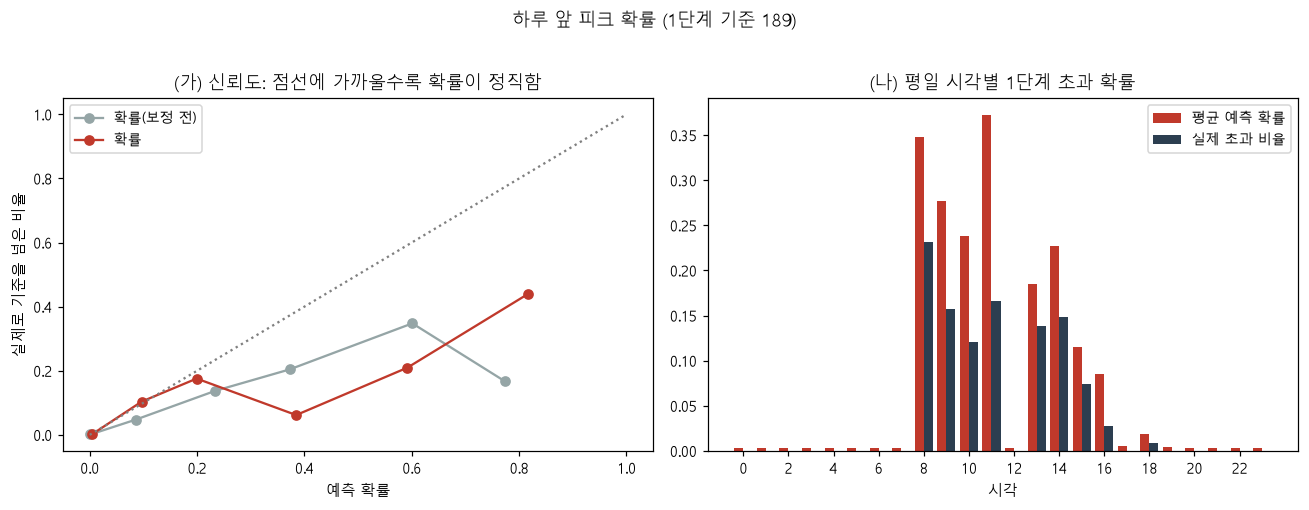

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
bins = [0, 0.05, 0.15, 0.3, 0.5, 0.7, 1.0]
for c, col in [("확률(보정 전)", "#95a5a6"), ("확률", "#c0392b")]:
    g = dayp.groupby(pd.cut(dayp[c], bins, include_lowest=True)).agg(예측=(c, "mean"), 실제=("실제피크", "mean"), n=("실제피크", "size")).dropna()
    axes[0].plot(g["예측"], g["실제"], marker="o", color=col, label=c)
axes[0].plot([0, 1], [0, 1], ls=":", color="gray")
axes[0].set_xlabel("예측 확률"); axes[0].set_ylabel("실제로 기준을 넘은 비율"); axes[0].legend(fontsize=9)
axes[0].set_title("(가) 신뢰도: 점선에 가까울수록 확률이 정직함")
prof = dayp[dayp["하루종류"] == "평일가동"].groupby(dayp[dayp["하루종류"] == "평일가동"].index.hour)[["확률", "실제피크"]].mean()
axes[1].bar(prof.index - 0.2, prof["확률"], width=0.4, color="#c0392b", label="평균 예측 확률")
axes[1].bar(prof.index + 0.2, prof["실제피크"], width=0.4, color="#2c3e50", label="실제 초과 비율")
axes[1].set_xlabel("시각"); axes[1].set_xticks(range(0, 24, 2)); axes[1].legend(fontsize=9)
axes[1].set_title("(나) 평일 시각별 1단계 초과 확률")
fig.suptitle(f"하루 앞 피크 확률 (1단계 기준 {L1:.0f})", y=1.02)
fig.tight_layout(); save_fig(fig, "f16_하루앞_피크확률"); plt.show()

**해석**
- 하루 앞 확률의 브라이어 점수(0.0320)는 '항상 평균 확률을 말하는 것'(0.0322)과 거의 같습니다. 브라이어 점수는 확률 예측의 오차로, 낮을수록 좋습니다. 다만 이 비교 기준은 시험 기간의 실제 평균을 쓰므로 미리 알 수 없는 값입니다.
- 신뢰도 그림(가)을 보면 **확률이 실제보다 높게 나옵니다.** 평균 예측 확률은 0.060인데 실제 초과 비율은 0.033입니다.
- 가장 큰 원인은 **학습 기간과 시험 기간의 수준 차이**입니다. 가동일 칸 중 1단계를 넘은 비율이 학습 기간 9.0%에서 시험 기간 4.5%로 절반이 됐습니다. 과거 오차로 확률을 만들었으니 확률이 높게 나올 수밖에 없습니다.
- 보정은 3주차 이후에는 효과가 있었습니다(가동일 브라이어 0.0355 → 0.0263 등). 하지만 **1~2주차에는 오히려 나빠졌습니다.**
  - 1주차 보정 창(7/26~8/8)에는 하계 휴무 때문에 쓸 수 있는 가동일이 3일뿐이었습니다.
  - 2주차 보정 창에는 피크가 많았던 1주차가 들어갔습니다.
  - 한편 평균 정밀도(AP)는 0.245에서 0.367로 올랐습니다. 주마다 수준 차이가 바로잡힌 효과로 보입니다.
- 시각별 그림(나)에서는 예측 확률이 높은 시각(08시, 11시, 14시)과 실제로 자주 넘는 시각이 같은 모양입니다.
- 정리하면, 하루 앞 예측은 **'어느 시간대가 위험한가'는 맞히지만 확률의 크기는 과장돼 있고, '어느 날 그 시간대가 넘을까'는 맞히지 못합니다.**

### 2-1. 경보 문턱별 비교 — 놓친 피크가 헛경보보다 비싸다
확률이 몇 % 이상이면 경보를 울릴지(문턱)는 **놓친 피크 1회의 비용**과 **헛경보 1회의 비용**의 비율로 정하는 것이 원칙입니다.
놓친 피크가 헛경보보다 k배 비싸면, **확률이 정확하다는 전제에서** 문턱 1/(1+k)가 비용을 가장 줄입니다(결정 이론의 표준 결과).
다만 위에서 본 것처럼 우리 확률은 실제보다 높게 나오는 편이라 이 전제가 완전히 맞지는 않습니다. 그래서 아래 표는 '최적 문턱'이 아니라 **문턱별 비교**로 봐야 합니다.
헛경보 비용(생산 일정 조정 부담)은 공장 자료가 없어 정확히 알 수 없으므로, 여러 비율을 나란히 놓습니다.

**놓친 피크는 얼마나 비싼가?** 목표전력을 넘는 15분이 한 번 생기면, 넘은 만큼이 **12개월 동안 기본요금에 반영**됩니다.
- 이 공장의 계약(산업용(을) 고압A 선택Ⅰ, 01-1 노트북 2-6)의 기본요금은 7,220원/kW·월입니다. 따라서 **목표를 1kW 넘으면 1년에 약 8.7만 원**(7,220 × 12), 10kW 넘으면 약 87만 원이 늘어납니다(부가세·기금 별도).
- 반면 헛경보 1회의 비용은 담당자가 설비 기동을 15~30분 미루거나 확인하는 정도입니다.
- 이렇게 비용이 크게 비대칭이라, 경보는 **놓치지 않는 것(재현율)을 우선**하고 헛경보는 어느 정도 감수하는 방향으로 설계합니다.

In [7]:
def boot_ratio(num, den, day, n_boot=2000):
    """비율(num 합 ÷ den 합)의 날짜 단위 부트스트랩 95% 범위. 같은 날의 칸들은 서로 닮아 있어 날짜를 단위로 다시 뽑음"""
    g = pd.DataFrame({"n": np.asarray(num, float), "d": np.asarray(den, float), "day": np.asarray(day)}).groupby("day").sum()
    ix = np.random.default_rng(42).integers(0, len(g), (n_boot, len(g)))
    b = g["n"].values[ix].sum(1) / np.maximum(g["d"].values[ix].sum(1), 1)
    lo, hi = np.percentile(b, [2.5, 97.5])
    return f"{lo:.2f} ~ {hi:.2f}"

def alarm_stats(y, alarm, dates, day):
    hit = alarm & (y == 1)
    tp = int(hit.sum()); fp = int((alarm & (y == 0)).sum()); fn = int((~alarm & (y == 1)).sum())
    rec, pre = tp / max(tp + fn, 1), tp / max(tp + fp, 1)
    return {"경보 칸": int(alarm.sum()), "맞힌 피크 칸": tp, "헛경보 칸": fp, "놓친 피크 칸": fn,
            "재현율 (놓치지 않은 비율)": round(rec, 2), "재현율 95% 범위": boot_ratio(hit, y == 1, day),
            "정밀도 (맞은 경보 비율)": round(pre, 2), "정밀도 95% 범위": boot_ratio(hit, alarm, day),
            "F1": round(2 * rec * pre / max(rec + pre, 1e-9), 2),
            "가동일 하루 평균 경보 칸": round(alarm.sum() / dates, 1)}

workdays = dayp[dayp["하루종류"] == "평일가동"]["date"].nunique()
rows = {}
for k in [1, 3, 5, 10]:
    thr = 1 / (1 + k)
    rows[f"놓친 피크 = 헛경보 × {k} (문턱 {thr:.0%})"] = alarm_stats(dayp["실제피크"], dayp["확률"] >= thr, workdays, dayp["date"])
rows["참고: 예측값이 기준을 넘을 때만"] = alarm_stats(dayp["실제피크"], dayp["하루앞_예측"] >= L1, workdays, dayp["date"])
day_alarm = pd.DataFrame(rows).T
save_table(day_alarm, "t19_하루앞_경보성능")
day_alarm

,경보 칸,맞힌 피크 칸,헛경보 칸,놓친 피크 칸,재현율 (놓치지 않은 비율),재현율 95% 범위,정밀도 (맞은 경보 비율),정밀도 95% 범위,F1,가동일 하루 평균 경보 칸
놓친 피크 = 헛경보 × 1 (문턱 50%),153,53,100,63,0.46,0.17 ~ 0.71,0.35,0.17 ~ 0.45,0.39,5.7
놓친 피크 = 헛경보 × 3 (문턱 25%),253,61,192,55,0.53,0.27 ~ 0.75,0.24,0.11 ~ 0.35,0.33,9.4
놓친 피크 = 헛경보 × 5 (문턱 17%),332,73,259,43,0.63,0.42 ~ 0.80,0.22,0.12 ~ 0.32,0.33,12.3
놓친 피크 = 헛경보 × 10 (문턱 9%),514,97,417,19,0.84,0.67 ~ 0.95,0.19,0.11 ~ 0.27,0.31,19.0
참고: 예측값이 기준을 넘을 때만,63,21,42,95,0.18,0.10 ~ 0.25,0.33,0.16 ~ 0.51,0.23,2.3


**해석**
- 문턱 9%에서는 피크 칸의 84%를 잡습니다. 대신 **가동일 하루 평균 19칸(약 4.8시간)** 경보가 울리고, 맞은 경보는 19%뿐입니다. 확률이 실제보다 높게 나오므로, 이 문턱이 실제로 비용을 가장 줄이는 값이라고 말할 수는 없습니다.
- 예측값이 기준을 넘을 때만 경보하면 피크 칸의 18%밖에 잡지 못합니다. 기준 곡선은 평균적인 하루를 그리므로, 짧게 솟는 피크까지 그리지는 않습니다.
- 결론적으로 하루 앞 경보는 **'내일 평일 오전·오후 피크 시간대를 주의하라'는 시간대 안내**로 쓰는 것이 맞습니다. 정확한 피크 시점은 1시간 앞 경보가 맡습니다.

### 2-2. 하루 단위로 보면 — "내일은 1단계를 넘는 날인가, 피크는 몇 시인가"
15분 칸 하나하나를 맞히는 대신, 생산 계획에 바로 쓰이는 **하루 단위 질문** 두 가지로 평가합니다(가동일만).
1. **내일 1단계를 넘는 칸이 하나라도 있을까?** 과거 가동일에서 '실제 하루 최대 − 기준 곡선의 하루 최대'가 얼마였는지를 모아, 내일 기준 곡선의 최대에 더해 확률을 계산합니다.
2. **하루 최대 전력은 몇 시에 나올까?** 기준 곡선이 가장 높은 시각과 실제 하루 최대 시각을 비교합니다.

In [8]:
from sklearn.metrics import roc_auc_score
day_rows = []
for st, en in zip(TEST_STARTS, TEST_ENDS):
    hist = slots[(slots.index < st) & slots["정답사용"]]
    curve = hist.groupby(CURVE_KEYS)["전력"].mean().rename("기준곡선")
    hw = hist[hist["하루종류"] == "평일가동"].join(curve, on=CURVE_KEYS)
    gap = (hw.groupby("date")["전력"].max() - hw.groupby("date")["기준곡선"].max()).values   # 과거 '실제 최대 − 곡선 최대'
    te = dayp[(dayp.index >= st) & (dayp.index < en) & (dayp["하루종류"] == "평일가동")]
    for dte, g in te.groupby("date"):
        cmax = g["하루앞_예측"].max()
        day_rows.append({"date": dte, "곡선최대": cmax, "실제최대": g["전력"].max(),
                         "확률": np.mean(cmax + gap >= L1), "실제초과": int(g["전력"].max() >= L1),
                         "예측피크시각": g["하루앞_예측"].idxmax(), "실제피크시각": g["전력"].idxmax()})
dl = pd.DataFrame(day_rows)
dl["시각차(시간)"] = ((dl["실제피크시각"] - dl["예측피크시각"]).dt.total_seconds() / 3600).abs()
print(f"가동일 {len(dl)}일 중 실제로 1단계를 넘은 날: {dl['실제초과'].sum()}일")
print(f"'넘는 날' 확률의 구분력(AUC, 0.5=동전 던지기, 1=완벽): {roc_auc_score(dl['실제초과'], dl['확률']):.2f}")
print(f"브라이어 점수: {brier_score_loss(dl['실제초과'], dl['확률']):.3f} (항상 평균을 말할 때 {brier_score_loss(dl['실제초과'], np.full(len(dl), dl['실제초과'].mean())):.3f})")
print(f"하루 최대 시각: 1시간 이내로 맞힌 날 {(dl['시각차(시간)'] <= 1).mean():.0%}, 3시간 이내 {(dl['시각차(시간)'] <= 3).mean():.0%}")
print("예측한 피크 시각:", dl["예측피크시각"].dt.strftime("%H:%M").value_counts().to_dict())
print("실제 피크 시각(시):", dl["실제피크시각"].dt.hour.value_counts().sort_index().to_dict())
save_table(dl.assign(date=dl["date"].dt.strftime("%m/%d")).set_index("date").round(2), "t23_하루단위_피크예측")

가동일 27일 중 실제로 1단계를 넘은 날: 20일
'넘는 날' 확률의 구분력(AUC, 0.5=동전 던지기, 1=완벽): 0.42
브라이어 점수: 0.215 (항상 평균을 말할 때 0.192)
하루 최대 시각: 1시간 이내로 맞힌 날 41%, 3시간 이내 70%
예측한 피크 시각: {'08:30': 26, '08:15': 1}
실제 피크 시각(시): {8: 9, 9: 3, 10: 4, 11: 6, 15: 4, 16: 1}


**해석**
- 가동일 27일 중 20일이 1단계를 넘었습니다. **거의 모든 가동일이 1단계 위험일**이라, '넘는 날'을 고르는 구분력은 동전 던지기 수준(AUC 0.42)입니다. AUC는 넘는 날과 안 넘는 날을 확률로 얼마나 잘 가르는지를 나타냅니다.
- 피크 시각도 기준 곡선은 거의 매일 **08:30**을 가리킵니다(27일 중 26일). 실제 하루 최대는 08시(9일), 11시(6일), 10시·15시(각 4일)로 퍼져 있습니다. 그래서 1시간 이내로 맞힌 날은 41%, 3시간 이내는 70%입니다.
- 생산계획만으로는 **'오늘 특히 높을 날'과 '정확한 피크 시각'을 미리 알 수 없습니다.**

### 2-3. 기온 예보를 더하면 — "더운 날은 피크가 높다"
생산계획만으로는 어느 날 피크가 더 높을지 알 수 없었습니다. 그런데 오류 분석(5절)과 01-1 노트북에서 **더운 날 주간 전력이 높다**는 신호가 있었습니다.
그래서 **가동일의 하루 최대 전력을 주간(08~16시) 평균 기온으로 설명하는 간단한 직선 모델**을 학습 기간으로 만들고, '넘는 날' 확률을 다시 계산합니다.

> 주의: 시험 기간의 **실제 기온**을 쓰므로 '기온 예보가 정확하다면' 얻을 수 있는 성능입니다. 실제 운영에서는 기상청 예보(전날 발표)를 씁니다.

학습 기간에서 얻은 기울기: 주간 기온 1℃ ↑ → 하루 최대 전력 약 2.3 ↑ (마지막 시험 주 기준)
시험 기간 가동일의 하루 최대와 주간 기온의 상관: 0.44


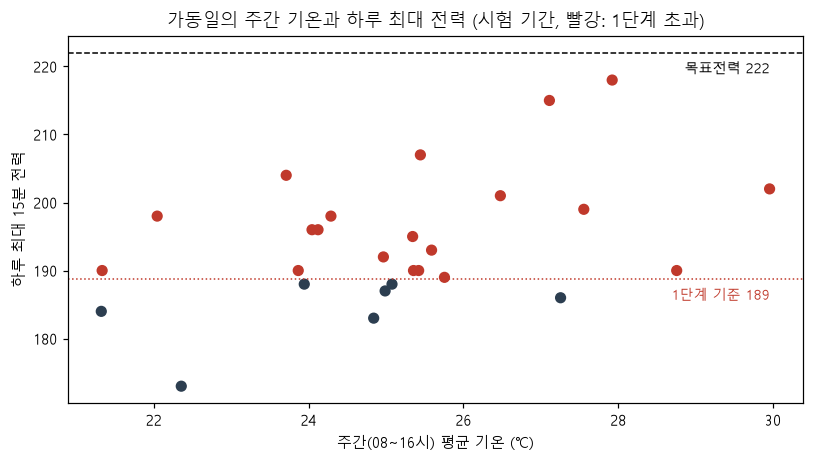

,생산계획만 (기준 곡선),기온 예보 추가,항상 평균 확률
"구분력 (AUC, 높을수록 좋음)",0.421,0.582,0.500
브라이어 점수 (낮을수록 좋음),0.215,0.206,0.192


In [9]:
from sklearn.linear_model import LinearRegression
def day_temp(df):
    w = df[(df["하루종류"] == "평일가동")]
    return w.groupby("date").agg(실제최대=("전력", "max"),
                                 주간기온=("기온", lambda x: x[(x.index.hour >= 8) & (x.index.hour < 17)].mean()))
rows = []
for st, en in zip(TEST_STARTS, TEST_ENDS):
    tr = day_temp(slots[(slots.index < st) & slots["정답사용"]])
    lr = LinearRegression().fit(tr[["주간기온"]], tr["실제최대"])
    res = tr["실제최대"] - lr.predict(tr[["주간기온"]])
    te = day_temp(slots[(slots.index >= st) & (slots.index < en) & slots["정답사용"]])
    te["예측최대"] = lr.predict(te[["주간기온"]])
    te["확률(기온)"] = [np.mean(m + res.values >= L1) for m in te["예측최대"]]
    te["기울기"] = lr.coef_[0]
    rows.append(te)
dt = pd.concat(rows)
dl2 = dl.set_index("date").join(dt[["주간기온", "예측최대", "확률(기온)", "기울기"]])
comp = pd.DataFrame({
    "생산계획만 (기준 곡선)": [roc_auc_score(dl2["실제초과"], dl2["확률"]), brier_score_loss(dl2["실제초과"], dl2["확률"])],
    "기온 예보 추가": [roc_auc_score(dl2["실제초과"], dl2["확률(기온)"]), brier_score_loss(dl2["실제초과"], dl2["확률(기온)"])],
    "항상 평균 확률": [0.5, brier_score_loss(dl2["실제초과"], np.full(len(dl2), dl2["실제초과"].mean()))],
}, index=["구분력 (AUC, 높을수록 좋음)", "브라이어 점수 (낮을수록 좋음)"]).round(3)
save_table(comp, "t24_하루단위_넘는날_예측")
print(f"학습 기간에서 얻은 기울기: 주간 기온 1℃ ↑ → 하루 최대 전력 약 {dl2['기울기'].iloc[-1]:.1f} ↑ (마지막 시험 주 기준)")
print(f"시험 기간 가동일의 하루 최대와 주간 기온의 상관: {dl2['실제최대'].corr(dl2['주간기온']):.2f}")

fig, ax = plt.subplots(figsize=(7.5, 4.3))
c = np.where(dl2["실제초과"] == 1, "#c0392b", "#2c3e50")
ax.scatter(dl2["주간기온"], dl2["실제최대"], c=c, s=40)
ax.axhline(L1, color="#c0392b", ls=":", lw=1); ax.text(dl2["주간기온"].max(), L1 - 3, f"1단계 기준 {L1:.0f}", fontsize=9, color="#c0392b", ha="right")
ax.axhline(TARGET, color="black", ls="--", lw=1); ax.text(dl2["주간기온"].max(), TARGET - 3, f"목표전력 {TARGET:.0f}", fontsize=9, ha="right")
ax.set_xlabel("주간(08~16시) 평균 기온 (℃)"); ax.set_ylabel("하루 최대 15분 전력")
ax.set_title("가동일의 주간 기온과 하루 최대 전력 (시험 기간, 빨강: 1단계 초과)")
fig.tight_layout(); save_fig(fig, "f21_기온과_하루최대"); plt.show()
comp

**해석**
- 주간 기온이 1℃ 오르면 하루 최대 전력이 약 2~3 높아지는 관계가 나왔습니다. 학습 기간만으로 맞춘 1주차 모델은 2.0, 마지막 주 모델은 2.3이고, 마지막 주 모델에는 1~4주차 시험 기간도 학습에 들어갔습니다. 시험 기간의 상관은 0.44입니다.
- 그림 21에서 시험 기간 가장 높은 두 날(215, 218)은 주간 기온이 27~28℃인 더운 날이었습니다. 하지만 22~24℃인 날에도 198~204가 나옵니다.
- 기온을 더하면 구분력이 0.42에서 0.58로 오르지만, 브라이어 점수는 여전히 '항상 평균 확률'보다 나쁩니다(0.206 vs 0.192). 게다가 넘지 않은 날이 7일뿐이라 이 차이에 큰 의미를 두기 어렵습니다.
- 5-1절에서 보듯, 기온 효과의 상당 부분은 **시기 차이**(8월 초가 덥고 9월이 서늘하면서 피크 수준도 달라짐)와 겹칩니다.
- 그래서 기온은 **'더운 날은 주의'라는 보조 규칙 정도로만** 쓰는 것이 안전합니다.

## 3. 1시간 앞 피크 경보 — "곧 피크가 온다"

매 정시에 다음 1시간의 15분 칸 4개를 예측하고, **예측값이 '기준 − 여유값' 이상이면 경보**를 울립니다.
여유값을 크게 하면 피크를 덜 놓치지만 헛경보가 늘어납니다.

**여유값을 정하는 방법**: 1시간 앞 최종 모델은 Chronos-2를 포함해 시험 기간에만 예측값이 있습니다. 그래서 **1주차로 여유값을 정하고, 나머지 2~5주차로 평가**합니다.
기준은 '1주차에서 1단계 피크 칸의 90% 이상을 잡는 가장 작은 여유값'입니다.

In [10]:
h = hour[hour["정답사용"]].copy()
h["실제피크"] = (h["정답"] >= L1).astype(int)
wk1 = h[h["시험주"] == "08/09"]; rest = h[h["시험주"] != "08/09"]
MARGINS = list(range(0, 21))
recall_wk1 = {m: ((wk1[FINAL_H] >= L1 - m) & (wk1["실제피크"] == 1)).sum() / max(wk1["실제피크"].sum(), 1) for m in MARGINS}
MARGIN = min(m for m in MARGINS if recall_wk1[m] >= 0.9)
print(f"1주차 1단계 피크 칸: {wk1['실제피크'].sum()}개 → 고른 여유값: {MARGIN} (1주차 재현율 {recall_wk1[MARGIN]:.2f})")

rest_days = rest[rest["하루종류"] == "평일가동"]["date"].nunique()
rows = {}
for name, col in [("최종 모델 (선형 회귀 + Chronos-2)", FINAL_H), ("선형 회귀", "선형 회귀"), ("Chronos-2", "Chronos-2 (+가동 계획)"), ("기준 곡선만", "기준 곡선만")]:
    rows[f"{name}, 여유값 0"] = alarm_stats(rest["실제피크"], rest[col] >= L1, rest_days, rest["date"])
    rows[f"{name}, 여유값 {MARGIN}"] = alarm_stats(rest["실제피크"], rest[col] >= L1 - MARGIN, rest_days, rest["date"])
hour_alarm = pd.DataFrame(rows).T
save_table(hour_alarm, "t20_1시간앞_경보성능")
hour_alarm

1주차 1단계 피크 칸: 56개 → 고른 여유값: 10 (1주차 재현율 0.93)


,경보 칸,맞힌 피크 칸,헛경보 칸,놓친 피크 칸,재현율 (놓치지 않은 비율),재현율 95% 범위,정밀도 (맞은 경보 비율),정밀도 95% 범위,F1,가동일 하루 평균 경보 칸
"최종 모델 (선형 회귀 + Chronos-2), 여유값 0",13,2,11,58,0.03,0.00 ~ 0.06,0.15,0.00 ~ 0.38,0.05,0.6
"최종 모델 (선형 회귀 + Chronos-2), 여유값 10",248,46,202,14,0.77,0.58 ~ 0.87,0.19,0.09 ~ 0.28,0.3,11.3
"선형 회귀, 여유값 0",71,11,60,49,0.18,0.08 ~ 0.26,0.15,0.04 ~ 0.29,0.17,3.2
"선형 회귀, 여유값 10",296,49,247,11,0.82,0.64 ~ 0.91,0.17,0.08 ~ 0.25,0.28,13.5
"Chronos-2, 여유값 0",9,0,9,60,0.0,0.00 ~ 0.00,0.0,0.00 ~ 0.00,0.0,0.4
"Chronos-2, 여유값 10",165,34,131,26,0.57,0.28 ~ 0.75,0.21,0.09 ~ 0.31,0.3,7.5
"기준 곡선만, 여유값 0",41,5,36,55,0.08,0.02 ~ 0.17,0.12,0.03 ~ 0.26,0.1,1.9
"기준 곡선만, 여유값 10",425,48,377,12,0.8,0.68 ~ 0.88,0.11,0.06 ~ 0.18,0.2,19.3


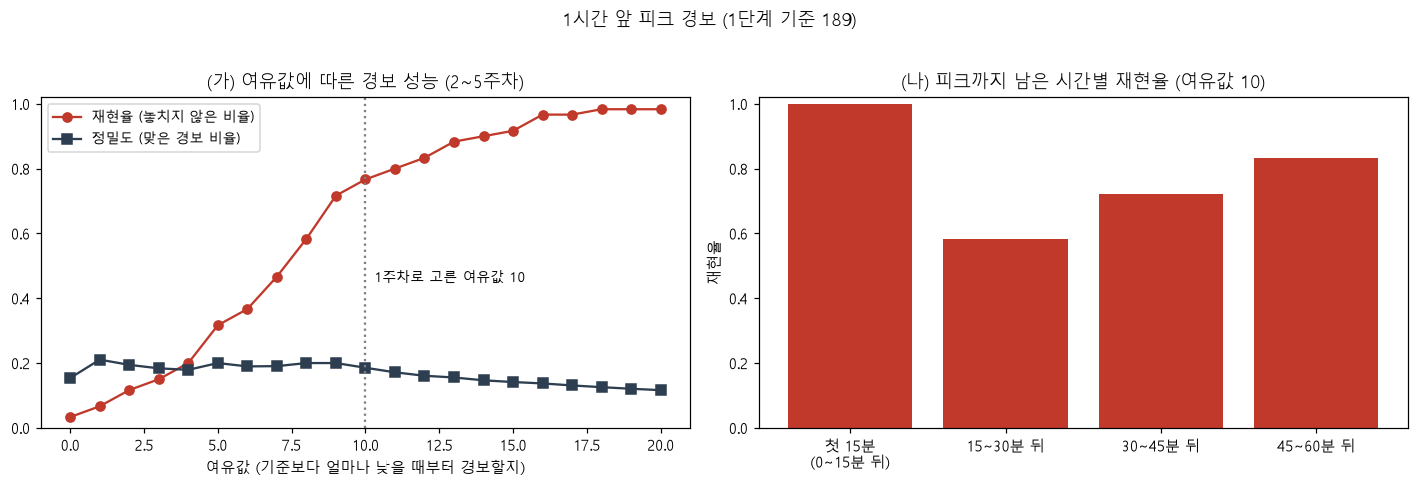

,재현율,정밀도,하루 경보 칸
여유값,,,
0,0.03,0.15,0.59
5,0.32,0.20,4.32
10,0.77,0.19,11.27
15,0.92,0.14,17.68
20,0.98,0.12,23.05


In [11]:
# 여유값에 따른 재현율·정밀도 변화 (2~5주차) + 경보까지 남은 시간
curve_rows = []
for m in MARGINS:
    a = rest[FINAL_H] >= L1 - m; y = rest["실제피크"]
    tp = (a & (y == 1)).sum()
    curve_rows.append({"여유값": m, "재현율": tp / y.sum(), "정밀도": tp / max(a.sum(), 1), "하루 경보 칸": a.sum() / rest_days})
tc = pd.DataFrame(curve_rows).set_index("여유값")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].plot(tc.index, tc["재현율"], marker="o", color="#c0392b", label="재현율 (놓치지 않은 비율)")
axes[0].plot(tc.index, tc["정밀도"], marker="s", color="#2c3e50", label="정밀도 (맞은 경보 비율)")
axes[0].axvline(MARGIN, color="gray", ls=":"); axes[0].text(MARGIN + 0.3, 0.45, f"1주차로 고른 여유값 {MARGIN}", fontsize=9)
axes[0].set_ylim(0, 1.02); axes[0].set_xlabel("여유값 (기준보다 얼마나 낮을 때부터 경보할지)"); axes[0].legend(fontsize=9)
axes[0].set_title("(가) 여유값에 따른 경보 성능 (2~5주차)")
a = rest[FINAL_H] >= L1 - MARGIN
step_rec = rest[rest["실제피크"] == 1].assign(경보=a).groupby("몇번째칸")["경보"].mean()
axes[1].bar([f"첫 15분\n(0~15분 뒤)", "15~30분 뒤", "30~45분 뒤", "45~60분 뒤"], step_rec.values, color="#c0392b")
axes[1].set_ylim(0, 1.02); axes[1].set_ylabel("재현율")
axes[1].set_title(f"(나) 피크까지 남은 시간별 재현율 (여유값 {MARGIN})")
fig.suptitle(f"1시간 앞 피크 경보 (1단계 기준 {L1:.0f})", y=1.02)
fig.tight_layout(); save_fig(fig, "f17_1시간앞_경보"); plt.show()
tc.round(2).iloc[[0, 5, 10, 15, 20]]

In [12]:
# (1) 여유값을 '앞선 주를 모두 모아' 매주 다시 고르면? (2주차는 1주차로, 3주차는 1~2주차로 ...)
weeks = sorted(h["시험주"].unique())
re_rows = []
for k in range(1, len(weeks)):
    past = h[h["시험주"].isin(weeks[:k])]; now = h[h["시험주"] == weeks[k]]
    rec = {m: ((past[FINAL_H] >= L1 - m) & (past["실제피크"] == 1)).sum() / max(past["실제피크"].sum(), 1) for m in range(0, 31)}
    m_k = min(m for m in rec if rec[m] >= 0.9)
    re_rows.append(now.assign(경보=now[FINAL_H] >= L1 - m_k, 여유값=m_k))
re = pd.concat(re_rows)
tp = (re["경보"] & (re["실제피크"] == 1)).sum()
print("매주 다시 고른 여유값:", dict(zip(weeks[1:], re.groupby("시험주")["여유값"].first())))
print(f"→ 2~5주차 재현율 {tp / re['실제피크'].sum():.2f}, 가동일 하루 평균 경보 {re['경보'].sum() / rest_days:.1f}칸")

# (2) 같은 재현율에서 모델별 경보 수 비교 (2~5주차를 보고 여유값을 맞춘 사후 비교)
def alarms_at_recall(col, target):
    for m in range(0, 41):
        a = rest[col] >= L1 - m
        if (a & (rest["실제피크"] == 1)).sum() / rest["실제피크"].sum() >= target:
            return a.sum() / rest_days
    return np.nan
match = pd.DataFrame({name: {f"재현율 {r:.0%}일 때 하루 경보 칸": round(alarms_at_recall(col, r), 1) for r in [0.8, 0.9]}
                      for name, col in [("최종 모델", FINAL_H), ("선형 회귀", "선형 회귀"), ("Chronos-2", "Chronos-2 (+가동 계획)"), ("기준 곡선만", "기준 곡선만")]}).T
save_table(match, "t25_같은재현율_경보수")
match

매주 다시 고른 여유값: {'08/16': 10, '08/23': 11, '08/30': 10, '09/06': 11}
→ 2~5주차 재현율 0.77, 가동일 하루 평균 경보 12.0칸


,재현율 80%일 때 하루 경보 칸,재현율 90%일 때 하루 경보 칸
최종 모델,12.7,16.7
선형 회귀,13.5,19.5
Chronos-2,13.9,15.5
기준 곡선만,19.3,22.3


**해석**
- **여유값 없이 '예측값 ≥ 기준'으로만 경보하면 피크를 거의 잡지 못합니다**(재현율 0.03). 모든 모델이 평균 수준을 예측하므로, 짧게 솟는 피크 칸에서는 예측이 기준에 못 미칩니다. 선형 회귀 단독(0.18), 기준 곡선(0.08)도 마찬가지입니다.
- 1주차에서 재현율 90%를 목표로 고른 **여유값 10**은 2~5주차에서 재현율 **0.77**(날짜 단위 95% 범위 0.58~0.87)에 그쳤습니다. 목표에는 못 미칩니다. F1은 0.30입니다. 이때 가동일 하루 평균 **11.3칸(약 2.8시간)** 경보가 울립니다.
- 여유값을 매주 '앞선 주를 모두 모아' 다시 골라도 10~11로 거의 같고 결과도 비슷합니다(재현율 0.77, 하루 12.0칸). 여유값 선택 자체는 안정적입니다.
- **같은 재현율에서 비교하면** 최종 모델의 경보가 기준 곡선만 쓸 때보다 적습니다.
  - 재현율 80%: 하루 12.7칸 vs 19.3칸 (약 34% 적음)
  - 재현율 90%: 16.7칸 vs 22.3칸 (약 25% 적음)
  - 재현율 90%에서는 Chronos-2 단독(15.5칸)이 조금 더 적습니다.
- 맞은 경보 비율(정밀도)은 0.19(95% 범위 0.09~0.28)로 낮습니다. 피크 사건 39회 중 25회가 15분 한 칸짜리 짧은 상승이라, 정확한 칸을 집어내기 어렵기 때문입니다. 경보는 '이 시간대에 피크가 올 수 있다'는 **주의 신호**로 보는 것이 맞습니다.
- 그림 17(나)의 몇 번째 칸별 재현율은 칸마다 피크가 6~24개뿐이라 들쭉날쭉합니다(15~30분 뒤 0.58 등). 칸별 차이는 우연일 가능성이 큽니다.

### 3-1. 피크 '사건' 단위로 보면
연속으로 기준을 넘은 칸들을 하나의 **피크 사건**으로 묶어, 사건마다 **시작 칸을 경보로 미리 잡았는지** 봅니다(2~5주차).

In [13]:
obs = slots[(slots.index >= TEST_STARTS[1]) & slots["정답사용"]]
over = obs["전력"] >= L1
run_id = (over != over.shift(1, fill_value=False)).cumsum()
ev = obs[over].assign(run=run_id[over]).groupby("run").apply(lambda g: pd.Series({"시작": g.index.min(), "끝": g.index.max(), "길이(칸)": len(g)}))
alarms = rest[rest[FINAL_H] >= L1 - MARGIN][["발행시각", "대상시각"]]
rows = []
for _, e in ev.iterrows():
    s0, e1 = e["시작"], e["끝"]
    at_start = ((alarms["대상시각"] == s0)).any()
    in_event = alarms["대상시각"].between(s0, e1).any()
    near = alarms["대상시각"].between(s0 - pd.Timedelta(minutes=30), s0).any()
    # 실제 준비 시간: 사건 시작 이전에 발행되어, '시작 30분 전 ~ 사건 끝'을 겨눈 경보 중 가장 이른 것
    cand = alarms[(alarms["발행시각"] <= s0) & alarms["대상시각"].between(s0 - pd.Timedelta(minutes=30), e1)]
    lead = (s0 - cand["발행시각"].min()).total_seconds() / 60 if len(cand) else np.nan
    rows.append({"시작": s0, "시각": s0.hour, "길이(칸)": e["길이(칸)"], "시작 칸 경보": at_start, "사건 중 어느 칸이든 경보": in_event,
                 "시작 칸 또는 30분 전 경보": at_start or near, "준비 시간(분)": lead})
caught = pd.DataFrame(rows)
n = len(caught)
summary_ev = pd.Series({k: f"{caught[k].sum()}회 ({caught[k].mean():.0%})" for k in ["시작 칸 경보", "시작 칸 또는 30분 전 경보", "사건 중 어느 칸이든 경보"]}, name=f"2~5주차 피크 사건 {n}회 중")
print(summary_ev.to_string())
print("\n실제 준비 시간(가장 이른 경보 ~ 사건 시작) 분포:", caught["준비 시간(분)"].value_counts(dropna=False).sort_index().to_dict())
print("사건 길이 분포(칸):", caught["길이(칸)"].value_counts().sort_index().to_dict())
print("시작 칸을 놓친 사건의 시작 시각:", caught[~caught["시작 칸 경보"]]["시각"].value_counts().sort_index().to_dict())

def wilson(k, n, z=1.96):
    p = k / n; c = (p + z * z / (2 * n)) / (1 + z * z / n); w = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / (1 + z * z / n)
    return f"{c - w:.2f} ~ {c + w:.2f}"
for k in ["시작 칸 경보", "시작 칸 또는 30분 전 경보"]:
    print(f"{k}: {caught[k].sum()}/{n} → 95% 범위 {wilson(caught[k].sum(), n)}")

시작 칸 경보             28회 (72%)
시작 칸 또는 30분 전 경보    31회 (79%)
사건 중 어느 칸이든 경보      30회 (77%)



실제 준비 시간(가장 이른 경보 ~ 사건 시작) 분포: {15.0: 3, 30.0: 8, 45.0: 14, 60.0: 2, 75.0: 5, nan: 7}
사건 길이 분포(칸): {1: 25, 2: 9, 3: 4, 5: 1}
시작 칸을 놓친 사건의 시작 시각: {9: 2, 10: 1, 11: 5, 14: 1, 15: 2}
시작 칸 경보: 28/39 → 95% 범위 0.56 ~ 0.83
시작 칸 또는 30분 전 경보: 31/39 → 95% 범위 0.64 ~ 0.89


**해석**
- 2~5주차의 피크 사건 39회를 세 가지 기준으로 봤습니다.
  - 시작 칸에 경보: **28회(72%, 95% 범위 56~83%)**
  - 사건 중 어느 칸이든 경보: 30회(77%)
  - 시작 칸이나 그 30분 전에 경보: 31회(79%, 95% 범위 64~89%)
- **실제 준비 시간**은 '사건 시작 전에 울린 경보 중 가장 이른 것'에서 사건 시작까지로 계산했습니다(시작 30분 전부터 사건 끝까지를 겨눈 경보).
  - 32회는 시작 전에 경보가 있었고, 그중 **21회는 45분 이상 전**에 울렸습니다(45분 14회, 60분 2회, 75분 5회).
  - 7회는 미리 울린 경보가 없었습니다.
  - 경보가 매 정시에 나가기 때문에, 준비 시간은 사건이 몇 분에 시작하는지에 따라 15분 단위로 정해집니다.
- 시작 칸을 놓친 사건은 주로 **오전 후반(11시 5회)**과 오후(14~15시)에 시작했습니다. 이미 가동 중인 상태에서 갑자기 올라가는 짧은 피크입니다.

### 3-2. 단순한 규칙과 비교하면 — 모델 경보는 무엇을 더 해 주나
정밀도 0.19가 낮아 보이지만, 피크가 원래 드물어서 어떤 방법이든 정밀도를 높이기 어렵습니다. 그래서 **예측 모델 없이도 만들 수 있는 두 규칙**과 나란히 비교합니다(2~5주차).
- **달력 규칙**: 가동일의 위험 시간대(08:00~12:00, 13:00~16:00)는 모두 경보
- **과거 초과율 규칙**: 학습 기간에 같은 '하루 종류 × 전날 가동 × 시각'에서 1단계를 넘은 비율이 높은 칸에 경보. 문턱은 모델과 재현율이 같아지도록 맞춤(사후 비교)
- 함께 보는 지표: F1(재현율과 정밀도의 조화평균), PR-AUC(문턱을 바꿔 가며 본 정밀도-재현율 곡선 아래 넓이. 피크 칸 비율이 약 0.02라 아무것도 모르는 예측은 약 0.02)

In [14]:
hr_ = rest["대상시각"].dt.hour
risk_ = ((hr_ >= 8) & (hr_ < 12)) | ((hr_ >= 13) & (hr_ < 16))
cal_alarm = (rest["하루종류"] == "평일가동") & risk_

parts = []
for st, en in zip(TEST_STARTS, TEST_ENDS):
    past = slots[(slots.index < st) & slots["정답사용"]]
    rate = (past["전력"] >= L1).groupby([past["하루종류"], past["전날가동"].astype(bool), past.index.hour]).mean()
    now = rest[(rest["대상시각"] >= st) & (rest["대상시각"] < en)]
    key = pd.MultiIndex.from_arrays([now["하루종류"], now["전날가동"].astype(bool), now["대상시각"].dt.hour])
    parts.append(pd.Series(rate.reindex(key).values, index=now.index))
past_rate = pd.concat(parts).reindex(rest.index).fillna(0)

model_alarm = rest[FINAL_H] >= L1 - MARGIN
y_ = rest["실제피크"]
target_rec = (model_alarm & (y_ == 1)).sum() / y_.sum()
thr_rate = max(t for t in np.unique(past_rate) if ((past_rate >= t) & (y_ == 1)).sum() / y_.sum() >= target_rec)
rate_alarm = past_rate >= thr_rate

base_cmp = pd.DataFrame({
    f"최종 모델 (여유값 {MARGIN})": alarm_stats(y_, model_alarm, rest_days, rest["date"]),
    "달력 규칙 (위험 시간대 전부)": alarm_stats(y_, cal_alarm, rest_days, rest["date"]),
    f"과거 초과율 규칙 (재현율 맞춤, 문턱 {thr_rate:.2f})": alarm_stats(y_, rate_alarm, rest_days, rest["date"]),
}).T
base_cmp["PR-AUC"] = [round(average_precision_score(y_, rest[FINAL_H]), 2), np.nan, round(average_precision_score(y_, past_rate), 2)]
base_cmp = base_cmp[["재현율 (놓치지 않은 비율)", "재현율 95% 범위", "정밀도 (맞은 경보 비율)", "정밀도 95% 범위", "F1", "PR-AUC", "가동일 하루 평균 경보 칸"]]
print(f"2~5주차 피크 칸 비율: {y_.mean():.3f}")
save_table(base_cmp, "t35_경보_단순규칙비교")
base_cmp

2~5주차 피크 칸 비율: 0.021


,재현율 (놓치지 않은 비율),재현율 95% 범위,정밀도 (맞은 경보 비율),정밀도 95% 범위,F1,PR-AUC,가동일 하루 평균 경보 칸
최종 모델 (여유값 10),0.77,0.58 ~ 0.87,0.19,0.09 ~ 0.28,0.3,0.19,11.3
달력 규칙 (위험 시간대 전부),0.98,0.95 ~ 1.00,0.1,0.05 ~ 0.15,0.17,NaN,28.0
"과거 초과율 규칙 (재현율 맞춤, 문턱 0.20)",0.77,0.64 ~ 0.88,0.1,0.05 ~ 0.17,0.18,0.10,20.0


**해석**
- 2~5주차에서 1단계를 넘는 칸은 **전체의 2.1%**뿐입니다. 아무 정보 없이 경보를 울리면 정밀도는 0.02 수준이므로, 최종 모델의 정밀도 0.19는 우연의 약 9배입니다.
- **달력 규칙**(위험 시간대 전부 경보)은 피크를 거의 다 잡지만(0.98) 가동일 하루 28칸, 즉 위험 시간대 내내 경보가 울려 정보가 되지 못합니다.
- **과거 초과율 규칙**을 모델과 같은 재현율(0.77)에 맞추면 하루 20칸이 필요합니다. **최종 모델은 같은 재현율을 하루 11.3칸으로 달성해 경보가 약 44% 적고, 정밀도(0.19 vs 0.10)와 F1(0.30 vs 0.18), PR-AUC(0.19 vs 0.10)가 모두 약 2배**입니다.
- 즉 예측 모델의 역할은 '위험 시간대 안에서도 **지금 이 1시간이 특히 위험한지**'를 골라 주는 것입니다. 재현율·정밀도의 95% 범위가 넓은 것은 시험 기간의 피크가 60칸(39회)뿐이기 때문이며, 결과를 해석할 때 이 불확실성을 함께 봐야 합니다.

### 3-3. 확률 분류기로 경보하면 — 회귀 예측 + 여유값 방식과 비교

지금 경보는 회귀 예측값이 '1단계 − 여유값'을 넘으면 울립니다. 피크가 드문 문제에서는 **'1단계를 넘을 확률'을 직접 맞히는 분류기**가 더 나을 수 있어 같은 조건으로 비교했습니다.
- **분류기**: LightGBM(클래스 가중, 작은 설정은 2장과 같음). 입력은 발행 시각에 알 수 있는 정보만 씁니다: 대상 칸의 기준 곡선, 직전 15분 실측, 편차(직전 실측 − 직전 기준 곡선), 몇 번째 칸, 시각, 하루 종류, 전날 가동, 요일.
- **학습**: 각 시험 주가 시작되기 전의 자료(7/2 이후)로만 학습하고 그 주를 예측합니다. 기준 곡선은 날마다 그날 이전 자료로 만듭니다.
- **문턱**: 여유값과 같은 방법으로, 1주차에서 재현율 90% 이상을 내는 가장 높은 확률 문턱을 고르고 2~5주차로 평가합니다.

In [15]:
# 3-3. 1단계 초과 확률 분류기 (발행 시각에 알 수 있는 정보만, 시험 주마다 다시 학습)
import lightgbm as lgb
obs_ = slots.copy()
curve_all = pd.Series(np.nan, index=obs_.index)
for d in obs_["date"].unique():
    hist = obs_[(obs_.index < d) & obs_["정답사용"]]
    if hist.empty: continue
    c = hist.groupby(CURVE_KEYS)["전력"].mean().rename("c")
    ix = obs_.index[obs_["date"] == d]
    curve_all.loc[ix] = obs_.loc[ix].join(c, on=CURVE_KEYS)["c"].values
P_ = obs_["전력"]; OK_ = obs_["정답사용"]
issue = obs_.index[obs_.index.minute == 0]
prev = issue - pd.Timedelta(minutes=15)
parts = []
for k in range(4):
    t = issue + pd.Timedelta(minutes=15 * k)
    keep = t.isin(obs_.index) & prev.isin(obs_.index)
    tt, ii, pp = t[keep], issue[keep], prev[keep]
    parts.append(pd.DataFrame({"발행시각": ii, "대상시각": tt, "몇번째칸": k + 1,
        "기준곡선": curve_all.reindex(tt).values, "직전실측": P_.reindex(pp).values,
        "편차": P_.reindex(pp).values - curve_all.reindex(pp).values,
        "칸번호": obs_["칸번호"].reindex(tt).values, "하루종류코드": obs_["하루종류코드"].reindex(tt).values,
        "전날가동": obs_["전날가동"].reindex(tt).astype(int).values, "요일": tt.dayofweek,
        "정답": P_.reindex(tt).values, "정답사용": OK_.reindex(tt).values}))
CF = pd.concat(parts, ignore_index=True)
CF = CF[CF["정답사용"] & CF[["기준곡선", "직전실측", "편차"]].notna().all(1)].copy()
CF["y"] = (CF["정답"] >= L1).astype(int)
XCOL = ["기준곡선", "직전실측", "편차", "몇번째칸", "칸번호", "하루종류코드", "전날가동", "요일"]
CPARAMS = dict(n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=30, subsample=0.8, subsample_freq=1,
               colsample_bytree=0.8, class_weight="balanced", random_state=42, verbose=-1)
CF["p"] = np.nan
for st, en in zip(TEST_STARTS, TEST_ENDS):
    tr = CF[CF["대상시각"] < st]; te = (CF["대상시각"] >= st) & (CF["대상시각"] < en)
    clf = lgb.LGBMClassifier(**CPARAMS).fit(tr[XCOL], tr["y"])
    CF.loc[te, "p"] = clf.predict_proba(CF.loc[te, XCOL])[:, 1]

# 3절의 평가 행(rest)과 1주차(wk1)에 맞춰 붙이기
key = ["발행시각", "대상시각"]
rest_c = rest.merge(CF[key + ["p"]], on=key, how="left"); wk1_c = wk1.merge(CF[key + ["p"]], on=key, how="left")
assert rest_c["p"].notna().all() and len(rest_c) == len(rest)
cand = np.sort(wk1_c["p"].unique())[::-1]
P_THR = next(t for t in cand if ((wk1_c["p"] >= t) & (wk1_c["실제피크"] == 1)).sum() / wk1_c["실제피크"].sum() >= 0.9)

def need_alarms(score, y, n_days, target):
    o = np.argsort(-score, kind="stable"); k = np.searchsorted(np.cumsum(y[o]), int(np.ceil(target * y.sum() - 1e-9))) + 1
    return round((score >= score[o][k - 1]).sum() / n_days, 1)
y_r = rest_c["실제피크"].values
rows = {f"회귀 예측 + 여유값 {MARGIN} (지금 방식)": alarm_stats(rest["실제피크"], rest[FINAL_H] >= L1 - MARGIN, rest_days, rest["date"]),
        f"확률 분류기 (1주차로 고른 문턱 {P_THR:.2f})": alarm_stats(rest_c["실제피크"], rest_c["p"] >= P_THR, rest_days, rest_c["date"])}
t_clf = pd.DataFrame(rows).T
t_clf["PR-AUC"] = [round(average_precision_score(y_r, rest[FINAL_H]), 3), round(average_precision_score(y_r, rest_c["p"]), 3)]
rec_now = (rest[FINAL_H] >= L1 - MARGIN)[rest["실제피크"] == 1].mean()
t_clf[f"재현율 {rec_now:.2f}에서 하루 경보 칸"] = [need_alarms(rest[FINAL_H].values, y_r, rest_days, rec_now), need_alarms(rest_c["p"].values + 1e-9 * rest[FINAL_H].values, y_r, rest_days, rec_now)]
t_clf["재현율 0.90에서 하루 경보 칸"] = [need_alarms(rest[FINAL_H].values, y_r, rest_days, 0.9), need_alarms(rest_c["p"].values + 1e-9 * rest[FINAL_H].values, y_r, rest_days, 0.9)]
t_clf = t_clf[["재현율 (놓치지 않은 비율)", "재현율 95% 범위", "정밀도 (맞은 경보 비율)", "정밀도 95% 범위", "F1", "PR-AUC",
               "가동일 하루 평균 경보 칸", f"재현율 {rec_now:.2f}에서 하루 경보 칸", "재현율 0.90에서 하루 경보 칸"]]
save_table(t_clf, "t52_확률분류기_경보비교")
print(f"1주차로 고른 확률 문턱 {P_THR:.3f} | 2~5주차 피크 칸 {y_r.sum()}개")
t_clf

1주차로 고른 확률 문턱 0.030 | 2~5주차 피크 칸 60개


,재현율 (놓치지 않은 비율),재현율 95% 범위,정밀도 (맞은 경보 비율),정밀도 95% 범위,F1,PR-AUC,가동일 하루 평균 경보 칸,재현율 0.77에서 하루 경보 칸,재현율 0.90에서 하루 경보 칸
회귀 예측 + 여유값 10 (지금 방식),0.77,0.58 ~ 0.87,0.19,0.09 ~ 0.28,0.3,0.185,11.3,11.2,16.3
확률 분류기 (1주차로 고른 문턱 0.03),0.93,0.84 ~ 1.00,0.12,0.06 ~ 0.18,0.21,0.200,22.0,12.7,17.0


**해석** — 표 52
- **분류기는 지금 방식보다 낫지 않았습니다.** 문턱과 무관한 PR-AUC는 0.200으로 회귀 예측값(0.185)과 비슷했고, 같은 재현율에서 필요한 경보 칸은 오히려 많았습니다(재현율 0.77: 12.7칸 대 11.2칸, 0.90: 17.0칸 대 16.3칸).
- 1주차로 고른 문턱(0.03)은 2~5주차에 재현율 0.93, 정밀도 0.12로 경보가 하루 22.0칸까지 늘었습니다. 1주차와 2~5주차의 피크 수준이 달라(3장 초과 비율 9.0% → 4.5%) 확률 문턱이 잘 옮겨지지 않았습니다.
- 피크 칸이 2.1%로 매우 드물고 1단계(189kW)가 평일 주간 수준에 가까워, 회귀 예측이 이미 '얼마나 높아질지'를 잘 담고 있습니다. 그래서 경보 규칙은 지금 방식(회귀 예측 + 여유값)을 유지합니다.
- 참고: 상위 5%를 피크로 정의한 별도 분석(1시간 최대, 양성 8~19%)에서는 분류기가 회귀 경보보다 F1이 높았습니다. 피크를 얼마나 드물게 정의하느냐에 따라 결론이 달라질 수 있습니다.

## 4. 오류 분석 — 예측은 어디서 크게 틀리나?

최종 모델의 오차를 조건별로 나눠 봅니다. **잘 맞는 조건과 실패하는 조건**을 구분하는 것이 목적입니다.

In [16]:
day_err = dayp.assign(오차=dayp["하루앞_예측"] - dayp["전력"], 절대오차=lambda d: d["오차"].abs())
h_err = h.assign(오차=h[FINAL_H] - h["정답"], 절대오차=lambda d: d["오차"].abs())

def cond_table(d, time_col=None):
    t = d.index if time_col is None else pd.DatetimeIndex(d[time_col])
    hr, mi = t.hour, t.minute
    conds = {
        "전체": np.ones(len(d), bool),
        "휴일 (기본 전력)": (d["하루종류"] == "휴일").values,
        "토요일": (d["하루종류"] == "토요일").values,
        "가동일 야간 (20~07시)": ((d["하루종류"] == "평일가동").values & ((hr >= 20) | (hr < 8))),
        "가동일 주간 (08~19시)": ((d["하루종류"] == "평일가동").values & (hr >= 8) & (hr < 20)),
        "  그중 정시 칸 (:00)": ((d["하루종류"] == "평일가동").values & (hr >= 8) & (hr < 20) & (mi == 0)),
        "  그중 정시가 아닌 칸 (:15·:30·:45)": ((d["하루종류"] == "평일가동").values & (hr >= 8) & (hr < 20) & (mi != 0)),
        "월요일 등 전날 휴일인 가동일": ((d["하루종류"] == "평일가동").values & ~d["전날가동"].astype(bool).values),
        "1단계 이상 고부하 칸": (d["전력" if "전력" in d else "정답"] >= L1).values,
    }
    return pd.DataFrame({k: {"칸 수": int(m.sum()), "MAE": round(d.loc[m, "절대오차"].mean(), 2),
                             "평균 오차 (+면 높게 예측)": round(d.loc[m, "오차"].mean(), 2)} for k, m in conds.items()}).T

err_table = pd.concat({"하루 앞": cond_table(day_err), "1시간 앞": cond_table(h_err, "대상시각")}, axis=1)
save_table(err_table, "t21_조건별_오차")
err_table

하루 앞                           1시간 앞         \
                                칸 수    MAE 평균 오차 (+면 높게 예측)     칸 수    MAE   
전체                           3478.0   7.32             1.30  3476.0   5.85   
휴일 (기본 전력)                    434.0   1.38             0.40   432.0   1.32   
토요일                           454.0   5.22            -1.56   454.0   3.84   
가동일 야간 (20~07시)              1296.0   5.85            -0.21  1296.0   5.03   
가동일 주간 (08~19시)              1294.0  11.52             4.12  1294.0   8.88   
  그중 정시 칸 (:00)               323.0  10.56             3.01   323.0   7.17   
  그중 정시가 아닌 칸 (:15·:30·:45)   971.0  11.84             4.49   971.0   9.45   
월요일 등 전날 휴일인 가동일              576.0  10.09             3.32   576.0   7.35   
1단계 이상 고부하 칸                  116.0  11.40           -11.20   116.0  10.60   

                                              
                            평균 오차 (+면 높게 예측)  
전체                                      0.43  
휴일 (기본 전력)                              0.53  
토요일                                    -0.05  
가동일 야간 (20~07시)                        -0.26  
가동일 주간 (08~19시)                         1.25  
  그중 정시 칸 (:00)                         0.86  
  그중 정시가 아닌 칸 (:15·:30·:45)             1.38  
월요일 등 전날 휴일인 가동일                        0.69  
1단계 이상 고부하 칸                          -10.32

In [17]:
# 고부하 칸의 큰 음수 오차는 '모델이 피크를 낮게 본다'와 '높은 칸만 골라서 생기는 착시(평균으로의 회귀)'가 섞인 값입니다.
# 그래서 반대로 '예측값' 구간별로 실제 평균을 봅니다. 예측값 구간에서 실제 평균이 예측과 비슷하면 모델 자체의 치우침은 작습니다.
def by_pred_bin(d, pred_col, true_col):
    b = pd.cut(d[pred_col], [0, 150, 170, 180, 189, 260], labels=["150 미만", "150~170", "170~180", "180~189", "189 이상"])
    return d.groupby(b).agg(칸수=(true_col, "size"), 예측평균=(pred_col, "mean"), 실제평균=(true_col, "mean")).round(1)
work_day = day_err[day_err["하루종류"] == "평일가동"]; work_h = h_err[h_err["하루종류"] == "평일가동"]
pred_bin = pd.concat({"하루 앞": by_pred_bin(work_day, "하루앞_예측", "전력"), "1시간 앞": by_pred_bin(work_h, FINAL_H, "정답")}, axis=1)
save_table(pred_bin, "t26_예측구간별_실제")
print("1시간 앞, 몇 번째 칸별 MAE:", h_err.groupby("몇번째칸")["절대오차"].mean().round(2).to_dict())
pred_bin

1시간 앞, 몇 번째 칸별 MAE: {1: 4.88, 2: 5.78, 3: 6.16, 4: 6.58}


하루 앞               1시간 앞              
           칸수   예측평균   실제평균    칸수   예측평균   실제평균
150 미만   1585  100.7  100.9  1621  101.0  101.3
150~170   326  160.6  156.5   345  161.0  160.7
170~180   196  176.5  172.5   312  175.3  173.5
180~189   424  183.4  176.9   258  183.7  180.6
189 이상     59  191.4  181.2    54  193.0  188.5

**해석**
- 오차는 대부분 **가동일 주간(08~19시)**에서 생깁니다(하루 앞 MAE 11.52, 1시간 앞 8.88). 휴일은 1.4 안팎으로 거의 정확합니다.
- **정시 칸(:00)**의 오차는 1시간 앞에서 더 작습니다(7.17 vs 9.45). 하지만 이것은 정시 칸이 언제나 발행 직후 첫 칸이라 예측 거리가 가장 짧기 때문입니다. 첫 칸부터 넷째 칸까지 오차가 점점 커집니다. 하루 앞에서는 정시와 나머지 칸의 차이가 작습니다(10.56 vs 11.84).
- **고부하 칸(1단계 이상)**의 평균 오차는 약 −10이지만, 이 숫자를 '모델이 피크를 낮게 본다'로 읽으면 안 됩니다. 실제값이 높은 칸만 골라서 보면, 치우침 없는 예측이라도 오차가 음수로 나오기 때문입니다(평균으로의 회귀).
- 그래서 위의 두 번째 표(표 26)에서 **예측값 구간별로 실제 평균**을 봤습니다. 해석은 그림 18 아래에 있습니다.
- 월요일처럼 전날 휴일인 가동일도 오차가 큰 편입니다(하루 앞 10.09).

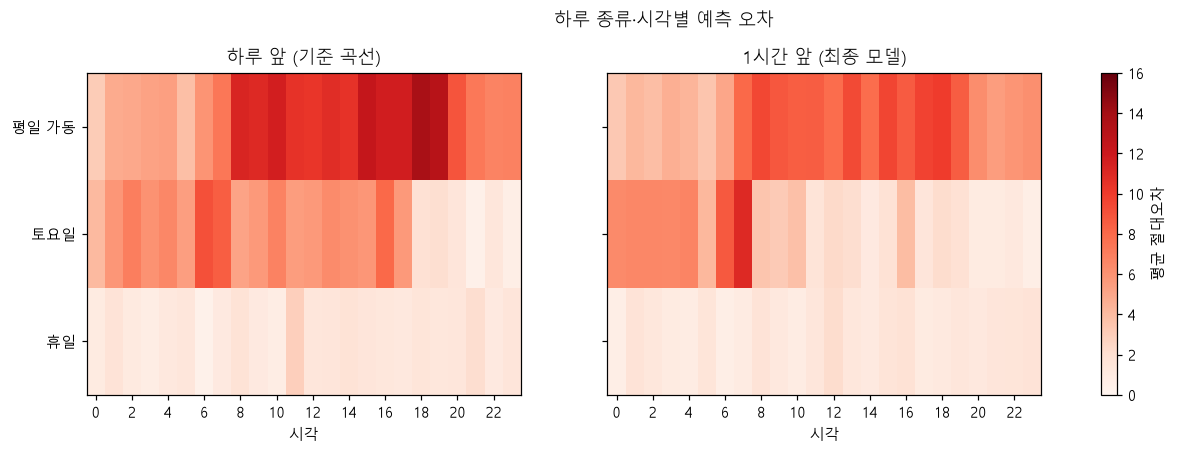

,MAE,평균오차,하루종류,계획생산량
date,,,,
08/16 (Mon),19.5,18.7,평일가동,10238
08/17 (Tue),13.3,12.0,평일가동,29279
08/09 (Mon),13.1,3.2,평일가동,20689
09/08 (Wed),12.1,4.8,평일가동,20831
08/28 (Sat),11.1,-10.7,토요일,1799
08/18 (Wed),10.1,7.1,평일가동,20063


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), sharey=True)
for ax, (name, d, tcol) in zip(axes, [("하루 앞 (기준 곡선)", day_err, None), ("1시간 앞 (최종 모델)", h_err, "대상시각")]):
    t = d.index if tcol is None else pd.DatetimeIndex(d[tcol])
    pv = d.assign(시=t.hour).pivot_table(index="하루종류", columns="시", values="절대오차", aggfunc="mean").reindex(["평일가동", "토요일", "휴일"])
    im = ax.imshow(pv.values, aspect="auto", cmap="Reds", vmin=0, vmax=16)
    ax.set_yticks(range(3)); ax.set_yticklabels(["평일 가동", "토요일", "휴일"])
    ax.set_xticks(range(0, 24, 2)); ax.set_xticklabels(range(0, 24, 2)); ax.set_xlabel("시각"); ax.set_title(name)
fig.colorbar(im, ax=axes, label="평균 절대오차")
fig.suptitle("하루 종류·시각별 예측 오차", y=1.03)
save_fig(fig, "f18_오차_히트맵"); plt.show()

top_days = day_err.groupby("date").agg(MAE=("절대오차", "mean"), 평균오차=("오차", "mean"), 하루종류=("하루종류", "first"),
                                         계획생산량=("일생산량", "first")).sort_values("MAE", ascending=False).head(6).round(1)
top_days.index = top_days.index.strftime("%m/%d (%a)")
save_table(top_days, "t22_오차가_큰_날")
top_days

**해석**
- 예측값 구간별로 보면(표 26), 1시간 앞 예측은 예측이 189 이상일 때 실제 평균이 188.5로 **거의 치우침이 없습니다.**
- 반면 하루 앞 예측은 높은 구간에서 오히려 **실제보다 높게** 예측합니다(예측 191.4 → 실제 181.2). 시험 기간의 피크 수준이 학습 기간보다 낮았기 때문입니다.
- 히트맵(그림 18)에서도 평일 08~19시가 가장 진하고, 1시간 앞 예측은 이 구간의 오차를 고르게 줄였습니다. 토요일 06~07시는 금요일 야간 근무의 새벽 가동 수준이 주마다 달라서(06시 기준 91~107) 오차가 큽니다.
- 오차가 가장 컸던 날은 다음과 같습니다.
  - **8/16(월, 대체공휴일 가동)**: 평균 +18.7로 예측이 크게 높았습니다. 대체공휴일이라 평소와 다르게 운영했을 가능성이 큽니다. 계획 생산량도 평소의 절반이었습니다. 다만 계획량이 비슷했던 8/30은 정상이었으므로 계획량만으로 설명되지는 않습니다.
  - **8/17**: 계획량은 가장 많았는데도 실제 하루 최대는 시험 기간 중 가장 낮았습니다(173).
  - **8/09(월)**: 하계 휴무가 끝난 뒤 첫 가동일입니다.
  - **8/28(토)**: 평균 −10.7로 예측이 낮았습니다. 토요일 오후에도 평소(약 25)보다 높은 전력이 쓰였고, 저녁부터는 계측 중단 구간이 이어졌습니다.
- 즉 **'평소와 다르게 운영한 날'**(공휴일 가동, 휴무 직후, 평소와 다른 토요일)에 오차가 몰립니다.

### 4-1. 경보가 놓친 피크와 헛경보는 어디에 몰리나 (1시간 앞, 2~5주차)

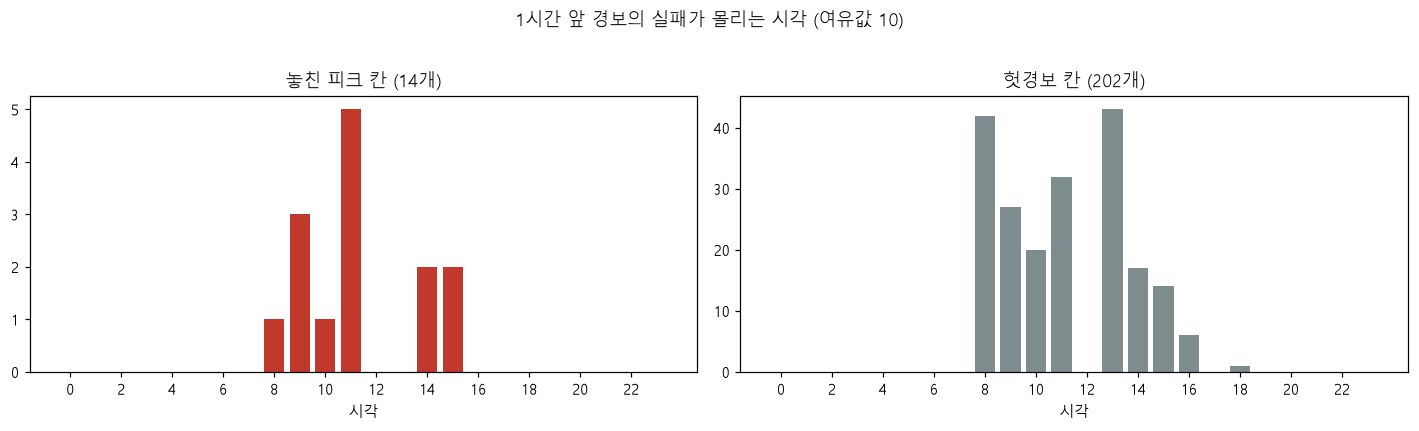

놓친 피크 칸의 날짜: {'09/02': 3, '08/16': 1, '08/26': 1, '08/20': 1, '08/23': 1, '09/01': 1}
헛경보 칸의 날짜: {'09/02': 16, '08/24': 16, '09/01': 14, '08/25': 13, '09/13': 13, '08/31': 13}
놓친 피크 칸의 실제 전력 평균 192.7, 예측 평균 174.6


In [19]:
a = rest[FINAL_H] >= L1 - MARGIN
miss = rest[(rest["실제피크"] == 1) & ~a]; fa = rest[(rest["실제피크"] == 0) & a]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, (name, d, col) in zip(axes, [(f"놓친 피크 칸 ({len(miss)}개)", miss, "#c0392b"), (f"헛경보 칸 ({len(fa)}개)", fa, "#7f8c8d")]):
    cnt = d["대상시각"].dt.hour.value_counts().reindex(range(24), fill_value=0)
    ax.bar(cnt.index, cnt.values, color=col); ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("시각"); ax.set_title(name)
fig.suptitle(f"1시간 앞 경보의 실패가 몰리는 시각 (여유값 {MARGIN})", y=1.02)
fig.tight_layout(); save_fig(fig, "f19_경보실패_시각"); plt.show()
print("놓친 피크 칸의 날짜:", miss["date"].dt.strftime("%m/%d").value_counts().head(6).to_dict())
print("헛경보 칸의 날짜:", fa["date"].dt.strftime("%m/%d").value_counts().head(6).to_dict())
print(f"놓친 피크 칸의 실제 전력 평균 {miss['정답'].mean():.1f}, 예측 평균 {miss[FINAL_H].mean():.1f}")

**해석**
- **놓친 피크 칸(14개)**은 오전 후반(11시 5개, 09시 3개)과 오후(14~15시)에 있습니다. 실제 평균 192.7을 174.6으로 예측해, 갑자기 솟은 짧은 피크를 따라가지 못했습니다.
- **헛경보(202칸)**는 **08시와 13시**에 가장 많습니다. 가동 시작과 점심 후 재가동 직후라 기준 곡선이 높게 잡히는 시각인데, 실제로는 189에 조금 못 미친 경우가 많았습니다.
- 헛경보는 특정한 날에 몰리지 않고 평일마다 비슷하게 나옵니다. 경보가 '평일 피크 시간대 주의'의 성격을 띤다는 뜻입니다.

### 4-2. 놓친 피크와 헛경보가 몰리는 조건 — 비율로 보기
그림 19는 개수라서 원래 경보가 많은 시각이 크게 보입니다. 그래서 조건별로 **놓친 비율**(놓친 피크 칸 ÷ 피크 칸)과 **헛경보 비율**(헛경보 칸 ÷ 경보 칸)을 계산합니다.
1시간 앞(여유값 적용, 2~5주차)과 하루 앞(문턱 9%, 전체 5주)을 함께 봅니다.

In [20]:
def rate_table(d, alarm, y, t, extra):
    t = pd.DatetimeIndex(t)
    hr = t.hour
    conds = {
        "오전 (08~11시)": (hr >= 8) & (hr < 12), "오후 (12~16시)": (hr >= 12) & (hr < 17), "저녁 (17~19시)": (hr >= 17) & (hr < 20),
        "월요일 등 전날 휴일": ~d["전날가동"].astype(bool).values, "그 외 가동일": d["전날가동"].astype(bool).values,
        "기온 24℃ 미만": (d["기온"] < 24).values, "기온 24~27℃": ((d["기온"] >= 24) & (d["기온"] < 27)).values, "기온 27℃ 이상": (d["기온"] >= 27).values,
    }
    conds.update(extra)
    out = {}
    for k, m in conds.items():
        m = np.asarray(m) & (d["하루종류"] == "평일가동").values
        pk = (y == 1).values & m; al = alarm.values & m
        out[k] = {"피크 칸": int(pk.sum()), "놓친 비율": round((pk & ~alarm.values).sum() / max(pk.sum(), 1), 2),
                  "놓친 비율 95% 범위": boot_ratio(pk & ~alarm.values, pk, d["date"].values),
                  "경보 칸": int(al.sum()), "헛경보 비율": round((al & (y == 0).values).sum() / max(al.sum(), 1), 2)}
    return pd.DataFrame(out).T

plan_med = dayp[dayp["하루종류"] == "평일가동"].groupby("date")["일생산량"].first().median()
r_h = rest.reset_index(drop=True)
ev_len = pd.Series(0, index=slots.index)
for _, e in ev.iterrows():
    ev_len.loc[e["시작"]:e["끝"]] = e["길이(칸)"]
len_h = r_h["대상시각"].map(ev_len).fillna(0).values
plan_h = r_h["date"].map(dayp.groupby("date")["일생산량"].first()).values
rt_h = rate_table(r_h, r_h[FINAL_H] >= L1 - MARGIN, r_h["실제피크"], r_h["대상시각"],
                  {"계획 생산량 중앙값 미만인 날": plan_h < plan_med, "계획 생산량 중앙값 이상인 날": plan_h >= plan_med,
                   "15분짜리 짧은 피크 (1칸)": len_h == 1, "30분 이상 이어진 피크 (2칸 이상)": len_h >= 2})
rt_h.loc[["15분짜리 짧은 피크 (1칸)", "30분 이상 이어진 피크 (2칸 이상)"], ["경보 칸", "헛경보 비율"]] = np.nan   # 사건 길이는 피크 칸에만 정의됨
rt_d = rate_table(dayp, dayp["확률"] >= 1 / 11, dayp["실제피크"], dayp.index,
                  {"계획 생산량 중앙값 미만인 날": (dayp["일생산량"] < plan_med).values, "계획 생산량 중앙값 이상인 날": (dayp["일생산량"] >= plan_med).values})
rate_tab = pd.concat({"1시간 앞 (여유값 적용)": rt_h, "하루 앞 (문턱 9%)": rt_d}, axis=1)
save_table(rate_tab, "t27_조건별_놓친비율_헛경보비율")
rate_tab

1시간 앞 (여유값 적용)                                 \
                                피크 칸 놓친 비율 놓친 비율 95% 범위 경보 칸 헛경보 비율   
오전 (08~11시)                       36  0.28  0.13 ~ 0.56  147   0.82   
오후 (12~16시)                       24  0.17  0.05 ~ 0.29  100    0.8   
저녁 (17~19시)                        0   0.0  0.00 ~ 0.00    1    1.0   
월요일 등 전날 휴일                       11  0.36  0.20 ~ 1.00   43   0.84   
그 외 가동일                           49   0.2  0.10 ~ 0.42  205   0.81   
기온 24℃ 미만                         21  0.24  0.00 ~ 0.50   97   0.84   
기온 24~27℃                         19  0.42  0.22 ~ 0.70  102   0.89   
기온 27℃ 이상                         20  0.05  0.00 ~ 0.07   49   0.61   
계획 생산량 중앙값 미만인 날                  28  0.29  0.15 ~ 0.63  121   0.83   
계획 생산량 중앙값 이상인 날                  32  0.19  0.06 ~ 0.53  127    0.8   
15분짜리 짧은 피크 (1칸)                  25  0.32  0.18 ~ 0.52  NaN    NaN   
30분 이상 이어진 피크 (2칸 이상)             35  0.17  0.04 ~ 0.46  NaN    NaN   

                      하루 앞 (문턱 9%)                                 
                              피크 칸 놓친 비율 놓친 비율 95% 범위 경보 칸 헛경보 비율  
오전 (08~11시)                     73   0.1  0.00 ~ 0.24  323    0.8  
오후 (12~16시)                     42  0.26  0.10 ~ 0.49  190   0.84  
저녁 (17~19시)                      1   1.0  0.00 ~ 1.00    1    1.0  
월요일 등 전날 휴일                     24  0.21  0.00 ~ 0.44   99   0.81  
그 외 가동일                         92  0.15  0.02 ~ 0.36  415   0.81  
기온 24℃ 미만                       31  0.35  0.00 ~ 0.62  137   0.85  
기온 24~27℃                       45  0.09  0.00 ~ 0.24  265   0.85  
기온 27℃ 이상                       40   0.1  0.03 ~ 0.33  112   0.68  
계획 생산량 중앙값 미만인 날                49   0.1  0.00 ~ 0.27  217    0.8  
계획 생산량 중앙값 이상인 날                67  0.21  0.04 ~ 0.51  297   0.82  
15분짜리 짧은 피크 (1칸)               NaN   NaN          NaN  NaN    NaN  
30분 이상 이어진 피크 (2칸 이상)          NaN   NaN          NaN  NaN    NaN

**해석** (괄호 안은 날짜 단위 95% 범위)
- **먼저 주의할 점**: 조건마다 피크 칸이 11~49개뿐이라 범위가 넓고, 대부분 서로 겹칩니다. 아래 차이는 **경향으로만 보고, 조건 사이에 확실한 차이가 있다고 단정하지 않습니다.**
- **1시간 앞 경보가 더 놓치는 경향이 있는 조건**
  - 오전 0.28(0.13~0.56)이 오후 0.17(0.05~0.29)보다 높음
  - 월요일 등 전날 휴일인 가동일 0.36(0.20~1.00)이 그 외 가동일 0.20(0.10~0.42)보다 높음
  - 15분짜리 짧은 피크 0.32(0.18~0.52)가 30분 이상 이어진 피크 0.17(0.04~0.46)보다 높음
- **기온**: 27℃ 이상에서 놓친 비율 0.05(0.00~0.07)로 가장 낮고, 24~27℃에서 0.42(0.22~0.70)로 가장 높습니다. 이 둘은 범위가 겹치지 않지만, 아래 5-1에서 보듯 기온 구간에는 시기(8월 초·말 vs 9월)가 섞여 있어 기온 때문이라고 말하기는 어렵습니다.
- **헛경보 비율**은 대부분의 조건에서 0.8 안팎으로 비슷합니다. 경보가 특정 조건에서만 헛울리는 것이 아니라, '주의 신호'의 성격이 전반적이라는 뜻입니다.
- **하루 앞 경보(문턱 9%)**는 오후 0.26과 서늘한 날 0.35에 더 많이 놓치는 경향입니다.
- **계획 생산량**이 많은 날과 적은 날의 차이는 크지 않습니다.

### 4-3. 1시간 최대로 보면 — 예측 단위를 바꾸면 결과가 달라지나

과제는 예측 단위를 정해 주지 않았습니다("향후 지정된 시간구간"). 우리는 요금이 15분 최대로 정해지므로 15분 단위를 주 예측으로 삼았습니다. 다만 경보는 '다음 1시간 안에 피크가 오는가'의 문제이기도 해서, 15분 예측 4칸의 최대를 1시간 최대 예측으로 보고 실제 1시간 최대(15분 값 4개 중 최대)와 비교했습니다. 4칸 모두 정답사용인 시간만 씁니다.

In [21]:
# 4-3. 1시간 최대 기준 평가 (15분 예측 4칸의 최대 vs 실제 15분 4칸의 최대)
fin_d = pd.read_csv(PRED_DIR / "final_day_ahead.csv", encoding="utf-8-sig", parse_dates=["ts", "date"])
fin_h = pd.read_csv(PRED_DIR / "final_hour_ahead.csv", encoding="utf-8-sig", parse_dates=["발행시각", "대상시각"])
def hourly_max(df, t, y, p):
    g = df.assign(시=df[t].dt.floor("h")).groupby("시").agg(실제=(y, "max"), 예측=(p, "max"), n=("정답사용", "sum"))
    return g[g["n"] == 4]
rows = []
for name, g in [("하루 앞 (기준 곡선)", hourly_max(fin_d, "ts", "전력", "하루앞_예측")),
                ("1시간 앞 (선형 회귀 + Chronos-2)", hourly_max(fin_h, "대상시각", "전력", "1시간앞_예측"))]:
    for per, s, e in [("8/9~9/14 (본 분석의 시험 기간)", "2021-08-09", "2021-09-15"), ("9/1~9/14", "2021-09-01", "2021-09-15")]:
        x = g[(g.index >= s) & (g.index < e)]
        err = x["예측"] - x["실제"]
        rows.append({"예측": name, "기간": per, "시간 수": len(x), "1시간 최대 MAE (kW)": round(err.abs().mean(), 2),
                     "평균 오차 (kW)": round(err.mean(), 2), "15분 MAE (kW, 같은 기간)": np.nan})
t_hr = pd.DataFrame(rows).set_index(["예측", "기간"])
for name, df, t, y, p in [("하루 앞 (기준 곡선)", fin_d, "ts", "전력", "하루앞_예측"), ("1시간 앞 (선형 회귀 + Chronos-2)", fin_h, "대상시각", "전력", "1시간앞_예측")]:
    for per, s, e in [("8/9~9/14 (본 분석의 시험 기간)", "2021-08-09", "2021-09-15"), ("9/1~9/14", "2021-09-01", "2021-09-15")]:
        x = df[df["정답사용"] & (df[t] >= s) & (df[t] < e)]
        t_hr.loc[(name, per), "15분 MAE (kW, 같은 기간)"] = round((x[p] - x[y]).abs().mean(), 2)
save_table(t_hr, "t55_1시간최대_평가")
t_hr

시간 수  1시간 최대 MAE (kW)  \
예측                        기간                                              
하루 앞 (기준 곡선)              8/9~9/14 (본 분석의 시험 기간)   868             7.06   
                          9/1~9/14                 335             6.72   
1시간 앞 (선형 회귀 + Chronos-2) 8/9~9/14 (본 분석의 시험 기간)   868             5.85   
                          9/1~9/14                 335             5.75   

                                                  평균 오차 (kW)  \
예측                        기간                                   
하루 앞 (기준 곡선)              8/9~9/14 (본 분석의 시험 기간)       -0.82   
                          9/1~9/14                     -2.33   
1시간 앞 (선형 회귀 + Chronos-2) 8/9~9/14 (본 분석의 시험 기간)       -2.26   
                          9/1~9/14                     -2.60   

                                                  15분 MAE (kW, 같은 기간)  
예측                        기간                                           
하루 앞 (기준 곡선)              8/9~9/14 (본 분석의 시험 기간)                 7.32  
                          9/1~9/14                               6.57  
1시간 앞 (선형 회귀 + Chronos-2) 8/9~9/14 (본 분석의 시험 기간)                 5.85  
                          9/1~9/14                               5.41

**해석** — 표 55
- 15분 예측 4칸의 최대로 본 1시간 최대 MAE는 시험 기간 전체에서 하루 앞 7.06kW, 1시간 앞 5.85kW로, 15분 MAE(7.32, 5.85kW)와 비슷합니다.
- 다만 평균 오차가 −0.8~−2.6kW로 **1시간 최대를 낮게 봅니다.** 15분 예측은 평탄해서, 네 칸의 최대를 취해도 실제 네 칸 중 튀는 값만큼 올라가지 못하기 때문입니다. 1시간 앞 경보에 여유값이 필요했던 이유와 같은 현상입니다.
- 1시간 최대를 직접 예측하는 모델은 이 치우침을 줄일 수 있습니다. 다만 요금은 15분 최대로 정해지고 4장의 비용 계산도 15분 단위라, 주 예측 단위는 15분으로 유지합니다.

## 5. 영향요인 — 무엇이 전력과 오차를 움직이나

예측 모델은 '하루 종류 + 시각'을 이미 반영합니다. 여기서는 그 위에 **남는 오차**를 다른 요인과 비교해, 무엇이 추가로 영향을 주는지 봅니다(하루 앞 예측, 가동일 주간).

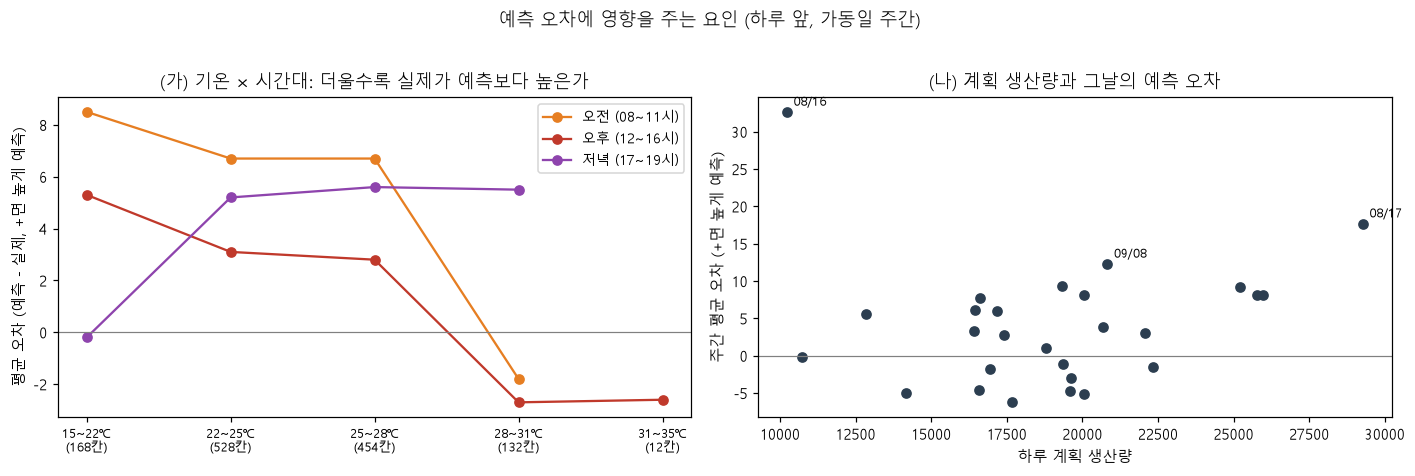

하루 계획 생산량과 주간 평균 오차의 상관: 0.06
하루 평균 기온과 주간 평균 오차의 상관: -0.22


시간대,오전 (08~11시),오후 (12~16시),저녁 (17~19시)
기온 구간,,,
"(15, 22]",8.5,5.3,-0.2
"(22, 25]",6.7,3.1,5.2
"(25, 28]",6.7,2.8,5.6
"(28, 31]",-1.8,-2.7,5.5
"(31, 35]",NaN,-2.6,NaN


In [22]:
wd = day_err[(day_err["하루종류"] == "평일가동") & day_err.index.hour.isin(range(8, 20))].copy()
wd["기온 구간"] = pd.cut(wd["기온"], [15, 22, 25, 28, 31, 35])
wd["시간대"] = np.where(wd.index.hour < 12, "오전 (08~11시)", np.where(wd.index.hour < 17, "오후 (12~16시)", "저녁 (17~19시)"))
temp_tab = wd.pivot_table(index="기온 구간", columns="시간대", values="오차", aggfunc="mean").round(1)
temp_n = wd.groupby("기온 구간").size()
daily = wd.groupby("date").agg(평균오차=("오차", "mean"), 계획생산량=("일생산량", "first"), 기온=("기온", "mean"), 요일=("date", lambda s: s.iloc[0].dayofweek))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for c, col in zip(temp_tab.columns, ["#e67e22", "#c0392b", "#8e44ad"]):
    axes[0].plot(range(len(temp_tab)), temp_tab[c], marker="o", color=col, label=c)
axes[0].axhline(0, color="gray", lw=0.8)
axes[0].set_xticks(range(len(temp_tab))); axes[0].set_xticklabels([f"{i.left:.0f}~{i.right:.0f}℃\n({n}칸)" for i, n in zip(temp_tab.index, temp_n)], fontsize=8.5)
axes[0].set_ylabel("평균 오차 (예측 - 실제, +면 높게 예측)"); axes[0].legend(fontsize=9)
axes[0].set_title("(가) 기온 × 시간대: 더울수록 실제가 예측보다 높은가")
axes[1].scatter(daily["계획생산량"], daily["평균오차"], color="#2c3e50")
axes[1].axhline(0, color="gray", lw=0.8)
for idx, r in daily.iterrows():
    if abs(r["평균오차"]) > 10: axes[1].annotate(idx.strftime("%m/%d"), (r["계획생산량"], r["평균오차"]), fontsize=8.5, xytext=(4, 4), textcoords="offset points")
axes[1].set_xlabel("하루 계획 생산량"); axes[1].set_ylabel("주간 평균 오차 (+면 높게 예측)")
axes[1].set_title("(나) 계획 생산량과 그날의 예측 오차")
fig.suptitle("예측 오차에 영향을 주는 요인 (하루 앞, 가동일 주간)", y=1.02)
fig.tight_layout(); save_fig(fig, "f20_영향요인"); plt.show()
print(f"하루 계획 생산량과 주간 평균 오차의 상관: {daily['계획생산량'].corr(daily['평균오차']):.2f}")
print(f"하루 평균 기온과 주간 평균 오차의 상관: {daily['기온'].corr(daily['평균오차']):.2f}")
temp_tab

**해석**
- **기온 × 시간대**(가): 오전·오후에는 서늘한 구간(15~22℃)에서 예측이 실제보다 높고(+8.5, +5.3), 더운 구간(28~31℃)에서는 오히려 낮습니다(−1.8, −2.7).
  - 다만 서늘한 구간은 대부분 9월과 8/17, 더운 구간은 8월 초·말의 날들입니다. 그래서 **시기에 따른 수준 차이**와 섞여 있습니다. 5-1에서 이를 통제해 다시 봅니다.
  - 31~35℃ 구간은 12칸뿐입니다.
- **계획 생산량**(나): 그날의 계획량과 예측 오차 사이에 뚜렷한 관계가 보이지 않습니다(27일, 상관 0.06). 8/16과 8/17이 크게 벗어났지만 방향이 반대입니다(계획량이 적었던 날, 많았던 날).

### 5-1. 남은 오차와 다른 변수의 관계 — 시기를 통제하고 보기
기온 구간별 비교에는 **시기**가 섞여 있습니다. 서늘한 날은 주로 9월과 8/17, 더운 날은 8월 초·말이고, 학습 기간보다 시험 기간의 피크 수준이 낮았습니다.
그래서 (1) 모델에 넣지 않은 변수들과 남은 오차의 상관을 보고, (2) **시험 주를 함께 넣은 회귀**로 기온 효과를 다시 계산합니다(가동일 주간, 하루 앞).

In [23]:
wd2 = day_err[(day_err["하루종류"] == "평일가동") & day_err.index.hour.isin(range(8, 20))].join(slots[["생산량", "습도", "강수량"]])
wd2["남은 오차 (실제 − 예측)"] = -wd2["오차"]
corr = wd2[["생산량", "기온", "습도", "강수량", "일생산량"]].corrwith(wd2["남은 오차 (실제 − 예측)"]).round(2)
corr.index = ["시간당 생산량 (같은 시각)", "기온", "습도", "강수량", "하루 계획 생산량"]
print("가동일 주간, 남은 오차와의 상관:"); print(corr.to_string())

# 시험 주를 함께 넣은 회귀: 남은 오차 = a × 기온 + (주마다 다른 상수)
wk_dum = pd.get_dummies(wd2["date"].dt.to_period("W-SUN").astype(str), drop_first=False).astype(float)
X = np.c_[wd2["기온"].values, wk_dum.values]
coef, *_ = np.linalg.lstsq(X, wd2["남은 오차 (실제 − 예측)"].values, rcond=None)
X0 = np.c_[wd2["기온"].values, np.ones(len(wd2))]
coef0, *_ = np.linalg.lstsq(X0, wd2["남은 오차 (실제 − 예측)"].values, rcond=None)
print(f"\n기온 1℃당 남은 오차: 시기 통제 전 {coef0[0]:.2f}, 시험 주를 통제한 뒤 {coef[0]:.2f}")
tab = pd.DataFrame({"남은 오차와의 상관": corr})
save_table(tab, "t28_남은오차_변수상관")

# 날짜 단위 부트스트랩으로 두 계수의 95% 범위
def temp_coef(df, control):
    yv = df["남은 오차 (실제 − 예측)"].values
    Xc = (np.c_[df["기온"].values, pd.get_dummies(df["date"].dt.to_period("W-SUN").astype(str)).astype(float).values]
          if control else np.c_[df["기온"].values, np.ones(len(df))])
    return np.linalg.lstsq(Xc, yv, rcond=None)[0][0]
groups = {d: g for d, g in wd2.groupby("date")}
dates_ = np.array(list(groups))
rng_ = np.random.default_rng(42)
boots = []
for _ in range(1000):
    b = pd.concat([groups[d] for d in rng_.choice(dates_, len(dates_))])
    boots.append((temp_coef(b, False), temp_coef(b, True)))
boots = np.array(boots)
temp_tab = pd.DataFrame({"기온 1℃당 남은 오차 (kW)": [round(coef0[0], 2), round(coef[0], 2)],
                         "95% 범위": [f"{np.percentile(boots[:, k], 2.5):.2f} ~ {np.percentile(boots[:, k], 97.5):.2f}" for k in (0, 1)]},
                        index=["시기 통제 전", "시험 주를 통제한 뒤"])
save_table(temp_tab, "t36_기온효과_범위")
temp_tab

가동일 주간, 남은 오차와의 상관:
시간당 생산량 (같은 시각)    0.04
기온                 0.11
습도                 0.02
강수량                0.06
하루 계획 생산량         -0.03

기온 1℃당 남은 오차: 시기 통제 전 0.68, 시험 주를 통제한 뒤 0.13


,기온 1℃당 남은 오차 (kW),95% 범위
시기 통제 전,0.68,-0.19 ~ 1.57
시험 주를 통제한 뒤,0.13,-0.89 ~ 1.08


**해석**
- 기준 곡선이 쓰지 않은 변수들과 남은 오차의 상관은 모두 작습니다(시간당 생산량 0.04, 기온 0.11, 습도 0.02, 강수량 0.06, 하루 계획 생산량 −0.03). '하루 종류 × 시각' 외에 **남은 오차를 크게 설명하는 변수는 없습니다.**
- 기온 1℃당 남은 오차는 시기 통제 전 0.68(95% 범위 −0.19~1.57), 시험 주를 통제한 뒤 0.13(−0.89~1.08)입니다(t36).
  - **두 값 모두 범위가 0을 포함합니다.** 즉 이 데이터(가동일 27일)로는 기온이 남은 오차를 움직인다는 것을 확인할 수 없습니다.
  - 통제 전후 값이 달라 보이지만 범위가 크게 겹쳐, '기온 효과의 대부분이 시기 효과'라고 단정할 수도 없습니다. 더운 날과 서늘한 날이 특정 시기에 몰려 있어 둘을 구분할 만큼 자료가 많지 않습니다.
- 따라서 이 데이터에서 피크와 오차를 좌우하는 요인은 다음과 같이 정리됩니다.
  1. **하루 종류 × 시각** (기본 모양)
  2. **시기에 따른 운영 수준 변화** (학습 기간보다 시험 기간의 피크가 낮음)
  3. **평소와 다른 운영** (공휴일 가동, 휴무 직후)
  - 기온의 독립적인 영향은 이 데이터로 확인되지 않고, 계획 생산량은 관계가 없습니다.

### 5-3. 변수 간 상호작용 — 어떤 조건이 함께 있을 때 전력과 피크가 커지나 (SHAP)

**왜 보나**
- 지금까지는 변수를 하나씩(하루 종류, 시각, 기온, 생산량) 봤습니다. 실제 공장에서는 '월요일 오전'처럼 **두 조건이 겹칠 때** 전력이 달라집니다.
- 그래서 설명용 LightGBM 두 개를 7/1~9/14의 정답사용 칸 전체로 학습하고, SHAP 값으로 각 변수의 몫과 변수 쌍의 상호작용 몫을 나눴습니다.
  - **전력 수준 모델**: 15분 전력(kW)을 설명
  - **피크 모델**: 1단계(189kW) 초과 여부를 설명(로그 오즈)
- 입력은 예측 모델에서 뺀 변수까지 포함한 운영 조건입니다: 하루 종류, 전날 가동, 시각, 요일, 기온, 습도, 시간별·하루 생산량.
- SHAP이란, 한 칸의 예측값을 '평균 + 변수별 몫'으로 나눈 값입니다. 상호작용 값은 두 변수가 **함께** 있을 때만 생기는 몫입니다.
- 이 절은 예측 성능이 아니라 **관계를 설명**하기 위한 분석입니다(학습 자료 안에서 계산).

In [24]:
# 5-3. 설명용 LightGBM + SHAP 주효과·상호작용 (7/1~9/14 정답사용 칸)
import lightgbm as lgb
import shap

EXPL = slots[slots["정답사용"]].copy()
EXPL["시각"] = EXPL.index.hour + EXPL.index.minute / 60
EXPL["요일"] = EXPL.index.dayofweek
EXPL["전날가동"] = EXPL["전날가동"].astype(int)
# 생산량은 넣지 않음(아래 참고 출력):
# - 시간별 생산량: 그 시간의 가동 여부(0이면 정지)를 거의 그대로 담고 실적 기록일 가능성이 있어, 시각·하루 종류의 몫을 대신 가져감
# - 하루 생산량: 날마다 값이 하나씩 달라 트리가 '어느 날인지'를 외우는 식별자로 쓰임. 평일 가동일 안에서는 하루 최대와 관계가 없음
FEAT = {"하루종류코드": "하루 종류", "전날가동": "전날 가동", "시각": "시각", "요일": "요일", "기온": "기온", "습도": "습도"}
X = EXPL[list(FEAT)].rename(columns=FEAT)
y_kw = EXPL["전력"].values
y_pk = (EXPL["전력"] >= L1).astype(int).values
PARAMS = dict(n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=30,
              subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=42, verbose=-1)
m_kw = lgb.LGBMRegressor(**PARAMS).fit(X, y_kw)
m_pk = lgb.LGBMClassifier(**PARAMS).fit(X, y_pk)

def shap_parts(model, X):
    inter = shap.TreeExplainer(model).shap_interaction_values(X)
    if isinstance(inter, list): inter = inter[1]
    if inter.ndim == 4: inter = inter[..., 1]
    main = np.abs(inter.sum(axis=2)).mean(0)                      # 변수별 SHAP 크기(상호작용 몫 포함)
    pair = np.abs(inter).mean(0) * 2                              # 쌍별 상호작용 크기(대칭이라 ×2)
    np.fill_diagonal(pair, 0)
    return inter, pd.Series(main, index=X.columns), pd.DataFrame(pair, index=X.columns, columns=X.columns)

I_kw, main_kw, pair_kw = shap_parts(m_kw, X)
I_pk, main_pk, pair_pk = shap_parts(m_pk, X)
t_main = pd.DataFrame({"전력 수준 모델: 평균 |SHAP| (kW)": main_kw.round(2),
                       "피크 모델: 평균 |SHAP| (로그 오즈)": main_pk.round(3)}).sort_values("전력 수준 모델: 평균 |SHAP| (kW)", ascending=False)
def top_pairs(pair, n=8):
    iu = np.triu_indices(len(pair), 1)
    s = pd.Series(pair.values[iu], index=[f"{pair.index[i]} × {pair.columns[j]}" for i, j in zip(*iu)])
    return s.sort_values(ascending=False).head(n)
tp_kw, tp_pk = top_pairs(pair_kw), top_pairs(pair_pk)
t_pair = pd.concat([tp_kw.rename("크기").to_frame().assign(모델="전력 수준 (kW)"),
                    tp_pk.rename("크기").to_frame().assign(모델="피크 (로그 오즈)")])
t_pair.index.name = "변수 쌍"; t_pair["크기"] = t_pair["크기"].round(3)
t_pair["주효과 대비 비율"] = [round(v / main_kw.max(), 2) if m.startswith("전력") else round(v / main_pk.max(), 2)
                         for v, m in zip(t_pair["크기"], t_pair["모델"])]
save_table(t_main, "t53_SHAP_주효과")
save_table(t_pair, "t54_SHAP_상호작용")
Xh = EXPL[["하루종류코드", "전날가동", "시각", "요일", "기온", "습도", "생산량", "일생산량"]]
mh = lgb.LGBMRegressor(**PARAMS).fit(Xh, y_kw)
ph = np.abs(mh.predict(Xh, pred_contrib=True)[:, :-1]).mean(0)
print("참고 — 생산량 두 열을 넣으면 평균 |SHAP|(kW):", dict(zip(Xh.columns, ph.round(1))))
wd_days = EXPL[EXPL["하루종류"] == "평일가동"].groupby("date").agg(생산량=("일생산량", "first"), 하루최대=("전력", "max"))
print(f"참고 — 평일 가동일 {len(wd_days)}일: 하루 생산량과 하루 최대의 상관 {wd_days['생산량'].corr(wd_days['하루최대']):.2f}")
print("전력 수준 모델 설명력(학습 자료 R²):", round(1 - ((m_kw.predict(X) - y_kw) ** 2).sum() / ((y_kw - y_kw.mean()) ** 2).sum(), 3))
display(t_main); t_pair

참고 — 생산량 두 열을 넣으면 평균 |SHAP|(kW): {'하루종류코드': np.float64(8.2), '전날가동': np.float64(2.8), '시각': np.float64(13.8), '요일': np.float64(1.0), '기온': np.float64(1.7), '습도': np.float64(0.5), '생산량': np.float64(30.6), '일생산량': np.float64(12.0)}
참고 — 평일 가동일 45일: 하루 생산량과 하루 최대의 상관 0.00
전력 수준 모델 설명력(학습 자료 R²): 0.984


,전력 수준 모델: 평균 |SHAP| (kW),피크 모델: 평균 |SHAP| (로그 오즈)
하루 종류,35.46,1.104
시각,20.24,1.740
요일,8.49,0.266
전날 가동,8.19,0.058
기온,1.57,0.725
습도,0.82,0.287


,크기,모델,주효과 대비 비율
변수 쌍,,,
하루 종류 × 시각,14.268,전력 수준 (kW),0.40
시각 × 요일,4.496,전력 수준 (kW),0.13
전날 가동 × 요일,4.386,전력 수준 (kW),0.12
전날 가동 × 시각,3.691,전력 수준 (kW),0.10
하루 종류 × 전날 가동,2.380,전력 수준 (kW),0.07
하루 종류 × 기온,1.342,전력 수준 (kW),0.04
하루 종류 × 요일,1.210,전력 수준 (kW),0.03
기온 × 습도,0.978,전력 수준 (kW),0.03
하루 종류 × 시각,0.493,피크 (로그 오즈),0.28


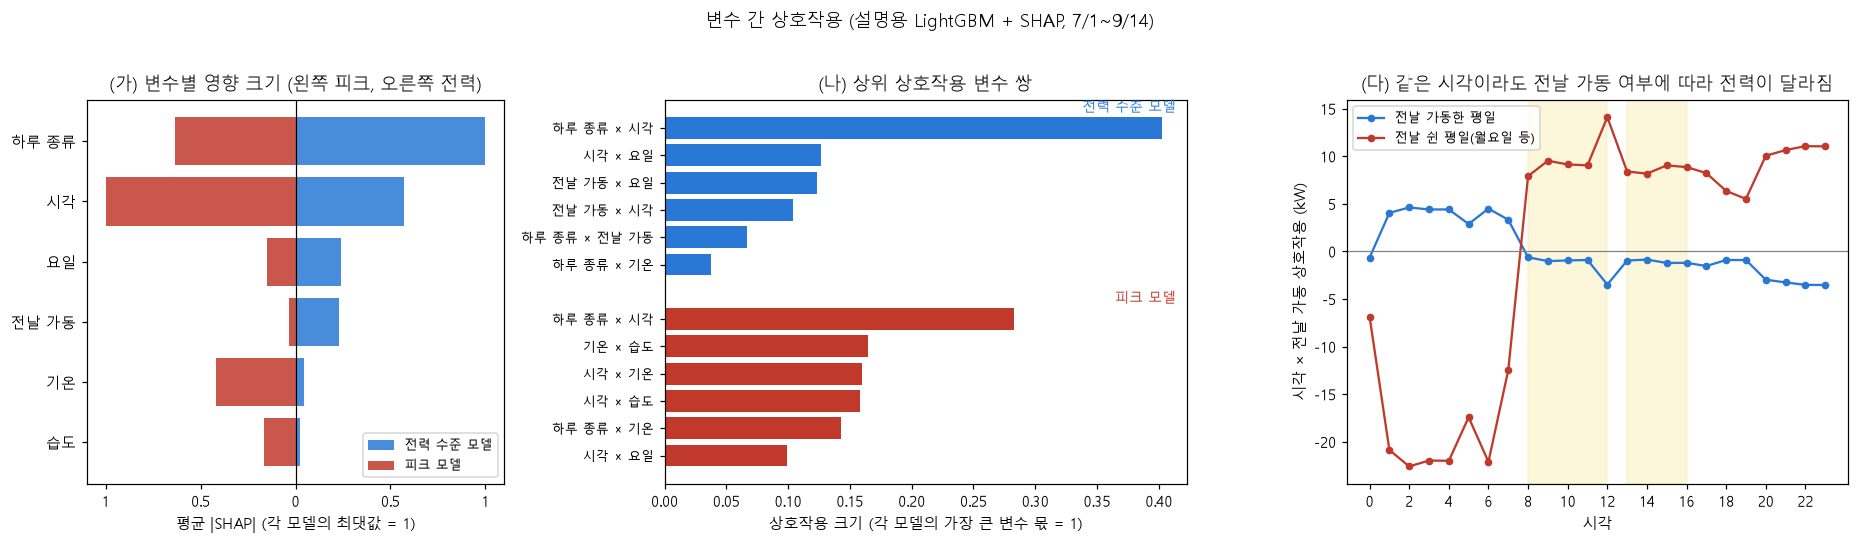

전날 쉰 평일 시각별 상호작용(kW): {0: -6.9, 1: -20.9, 2: -22.6, 3: -22.0, 4: -22.0, 5: -17.4, 6: -22.1, 7: -12.5, 8: 7.9, 9: 9.5, 10: 9.1, 11: 9.0, 12: 14.1, 13: 8.4, 14: 8.2, 15: 9.0, 16: 8.9, 17: 8.2, 18: 6.4, 19: 5.5, 20: 10.0, 21: 10.6, 22: 11.1, 23: 11.0}
전날 가동 평일 시각별 상호작용(kW): {0: -0.6, 1: 4.1, 2: 4.6, 3: 4.4, 4: 4.4, 5: 2.9, 6: 4.5, 7: 3.3, 8: -0.6, 9: -1.0, 10: -0.9, 11: -0.9, 12: -3.5, 13: -1.0, 14: -0.9, 15: -1.2, 16: -1.2, 17: -1.5, 18: -0.9, 19: -0.9, 20: -3.0, 21: -3.3, 22: -3.5, 23: -3.5}


In [25]:
# 그림 30: (가) 변수별 SHAP 크기, (나) 상위 상호작용 쌍, (다) 시각 × 전날 가동 상호작용(피크 모델, 평일 가동일)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), gridspec_kw={"width_ratios": [1, 1.25, 1.2]})
ax = axes[0]
order = main_kw.sort_values().index
ax.barh(order, main_kw[order] / main_kw.max(), color="#2a78d6", alpha=0.85, label="전력 수준 모델")
ax.barh(order, -(main_pk[order] / main_pk.max()), color="#c0392b", alpha=0.85, label="피크 모델")
ax.axvline(0, color="black", lw=0.8); ax.set_xlim(-1.1, 1.1)
ax.set_xticks([-1, -0.5, 0, 0.5, 1]); ax.set_xticklabels(["1", "0.5", "0", "0.5", "1"])
ax.set_xlabel("평균 |SHAP| (각 모델의 최댓값 = 1)"); ax.legend(fontsize=8.5, loc="lower right")
ax.set_title("(가) 변수별 영향 크기 (왼쪽 피크, 오른쪽 전력)")
ax = axes[1]
lab = list(tp_kw.index[:6]); val = list(tp_kw.values[:6] / main_kw.max())
lab2 = list(tp_pk.index[:6]); val2 = list(tp_pk.values[:6] / main_pk.max())
yy = np.arange(6)
ax.barh(yy + 7, val[::-1], color="#2a78d6"); ax.barh(yy, val2[::-1], color="#c0392b")
ax.set_yticks(list(yy + 7) + list(yy)); ax.set_yticklabels(lab[::-1] + lab2[::-1], fontsize=8.5)
ax.text(0.98, 12.6, "전력 수준 모델", ha="right", color="#2a78d6", fontsize=9, transform=ax.get_yaxis_transform())
ax.text(0.98, 5.6, "피크 모델", ha="right", color="#c0392b", fontsize=9, transform=ax.get_yaxis_transform())
ax.set_xlabel("상호작용 크기 (각 모델의 가장 큰 변수 몫 = 1)"); ax.set_title("(나) 상위 상호작용 변수 쌍")
ax = axes[2]
cols = list(X.columns); i_t, i_p = cols.index("시각"), cols.index("전날 가동")
wd_ = (EXPL["하루종류"] == "평일가동").values
inter_tp = I_kw[:, i_t, i_p] * 2                                   # 전력 수준 모델의 시각 × 전날 가동 상호작용 (kW)
hh_ = EXPL.index.hour.values
for flag, col, name in [(1, "#2a78d6", "전날 가동한 평일"), (0, "#c0392b", "전날 쉰 평일(월요일 등)")]:
    m_ = wd_ & (EXPL["전날가동"].values == flag)
    s_ = pd.Series(inter_tp[m_]).groupby(hh_[m_]).mean()
    ax.plot(s_.index, s_.values, marker="o", ms=4, color=col, label=name)
ax.axhline(0, color="gray", lw=0.8)
for lo, hi in [(8, 12), (13, 16)]: ax.axvspan(lo, hi, color="#f1c40f", alpha=0.15)
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("시각"); ax.set_ylabel("시각 × 전날 가동 상호작용 (kW)"); ax.legend(fontsize=8.5)
ax.set_title("(다) 같은 시각이라도 전날 가동 여부에 따라 전력이 달라짐")
fig.suptitle("변수 간 상호작용 (설명용 LightGBM + SHAP, 7/1~9/14)", y=1.02)
fig.tight_layout(); save_fig(fig, "f30_SHAP_상호작용"); plt.show()
s_off = pd.Series(inter_tp[wd_ & (EXPL["전날가동"].values == 0)]).groupby(hh_[wd_ & (EXPL["전날가동"].values == 0)]).mean()
s_on = pd.Series(inter_tp[wd_ & (EXPL["전날가동"].values == 1)]).groupby(hh_[wd_ & (EXPL["전날가동"].values == 1)]).mean()
print("전날 쉰 평일 시각별 상호작용(kW):", s_off.round(1).to_dict())
print("전날 가동 평일 시각별 상호작용(kW):", s_on.round(1).to_dict())

**해석** — 표 53·54, 그림 30
- **전력 수준**: 하루 종류(평균 |SHAP| 35.5kW), 시각(20.2kW)이 가장 크고, 요일(8.5kW)과 전날 가동(8.2kW)이 뒤따릅니다. 기온(1.6kW)과 습도(0.8kW)는 작습니다.
- **가장 큰 상호작용은 하루 종류 × 시각(14.3kW)**입니다. 같은 11시라도 가동일과 휴일의 차이가 시각마다 다르다는 뜻이며, 기준 곡선이 '하루 종류 × 시각'별 평균인 이유입니다. 그다음은 시각 × 요일(4.5kW), 전날 가동 × 요일(4.4kW), 전날 가동 × 시각(3.7kW)입니다.
- **그림 (다) — 전날 가동 × 시각**: 전날 쉰 평일은 새벽(1~6시)에 약 −22kW 낮고, 08시 이후 주간에는 약 +8~9kW 높습니다. 월요일처럼 쉬고 나서 한꺼번에 기동하는 날의 오전 피크(1장 상위 4칸 중 3칸)가 이 상호작용으로 나타납니다. 그래서 기준 곡선에 '전날 가동'을 넣었고, 4장에서 이런 날을 주의일로 둡니다.
- **피크(1단계 초과)**: 시각(1.74), 하루 종류(1.10), 기온(0.73) 순이고, 가장 큰 상호작용도 하루 종류 × 시각입니다. 기온이 들어간 상호작용(기온 × 습도, 시각 × 기온)은 5-1에서 본 것처럼 시기와 섞여 있어 기온 자체의 효과로 단정하지 않습니다.
- **생산량을 넣지 않은 이유**: 시간별 생산량은 그 시간의 가동 여부를 거의 그대로 담아(실적 기록일 가능성도 있음) 시각·하루 종류의 몫을 대신 가져갑니다. 하루 생산량은 날마다 값이 달라 트리가 날짜를 외우는 식별자로 쓰였고, 평일 가동일 45일에서 하루 최대와의 상관은 0.00이었습니다.
- **한계**: 학습 자료에서 함께 나타난 관계를 보여 줍니다(설명력 R² 0.98). 원인을 확인하려면 설비 계측이나 운영 실험이 필요합니다.

### 5-2. 1시간 앞 예측구간 — 얼마나 믿을 수 있나
3절의 경보는 예측값 하나로 판단합니다. 하지만 현장에서는 **"최악의 경우 다음 1시간에 몇 kW까지 갈 수 있나"**도 알고 싶습니다. 그래서 1시간 앞 예측에 **예측구간**을 붙입니다.

- **80% 예측구간**: 실제 전력이 10번 중 8번은 이 범위 안에 들어와야 하는 구간입니다. 90% 구간도 같은 뜻입니다.
- **커버리지**: 실제로 구간 안에 들어온 비율입니다. 80% 구간이면 0.80에 가까워야 정직한 구간입니다. 넓히기만 하면 1.0이 되므로 **폭**(구간의 크기)을 함께 봅니다.
- **pinball 점수**: 분위수(10%, 20%, … 값)가 얼마나 정확한지 보는 점수로, 낮을수록 좋습니다. 19개 분위수(5%~95%)의 평균을 씁니다.

**비교하는 네 가지 방법**
| 방법 | 만드는 법 |
|---|---|
| Chronos-2 분위수 그대로 | Chronos-2가 내는 10%·90% 등의 값을 그대로 사용 |
| 고정 conformal | 최종 예측값에, 과거에 실제가 예측에서 벗어난 정도(오차)의 분위수를 더함 |
| 적응형 conformal (ACI) | 위와 같되, 구간이 실제를 놓치면 조금 넓히고 맞히면 조금 좁히기를 매 정시 반복 |
| **Chronos-2 분위수 + conformal 보정** | Chronos-2의 분위수마다, 과거에 '실제 − 그 분위수'가 얼마였는지 보고 그만큼 옮김 |

conformal 예측은 '과거에 모델이 틀린 크기'로 구간을 만드는 방법으로, 어떤 모델에도 붙일 수 있습니다. 오차는 **몇 번째 칸(1~4) × 가동일 주간(08~19시)/그 외**로 나눠 모읍니다.

**같은 조건**: 보정에는 언제나 그 시험 주 **이전**의 예측과 실제만 씁니다. 1주차에도 보정 자료가 있도록, 시험 기간 전 4주(7/12~8/8)의 예측도 같은 방식(매주 확장 창)으로 만들었습니다. ACI의 갱신 속도는 **시험 전 기간(7/19~8/8)**에서만 골랐습니다.

In [26]:
from sklearn.linear_model import Ridge
TAUS = np.round(np.arange(0.05, 0.951, 0.05), 2)                  # 19개 분위수 (5%~95%)
Q_COLS = [f"q{round(t * 100):02d}" for t in TAUS]
I10, I90, I05, I95 = 1, 17, 0, 18                                   # 80% = 10~90%, 90% = 5~95%
WEEKS = pd.date_range("2021-07-12", TEST_STARTS[-1], freq="7D")     # 7/12~8/2: 보정 자료용, 8/9~: 시험 주
WEEK_ENDS = list(WEEKS[1:]) + [TEST_ENDS[-1]]
LIN_F = ["직전1", "곡선_대상", "곡선_직전", "편차"]

def hour_table():
    """02-2 노트북과 같은 1시간 앞 입력 표: 매 정시 발행, 다음 4칸"""
    yy = slots["전력"]; parts = []
    for step in range(4):
        d = pd.DataFrame(index=slots.index)
        d["몇번째칸"] = step + 1
        d["대상시각"] = slots.index + pd.Timedelta(minutes=15 * step)
        d["정답"] = yy.shift(-step)
        d["정답사용"] = slots["정답사용"].shift(-step).fillna(False).astype(bool)
        for c in ["칸번호", "하루종류코드", "전날가동"]:
            d["대상_" + c] = slots[c].astype(float).shift(-step)
        d["직전1"] = yy.shift(1)
        parts.append(d[d.index.minute == 0])
    out = pd.concat(parts).dropna(subset=["대상_칸번호"])
    return out[out.index > "2021-07-01"]

def add_curve(d, curve):
    d = d.copy()
    d["곡선_대상"] = d.join(curve, on=["대상_하루종류코드", "대상_전날가동", "대상_칸번호"])["기준곡선"].values
    d["곡선_직전"] = slots.loc[d.index - pd.Timedelta(minutes=15), CURVE_KEYS].join(curve, on=CURVE_KEYS)["기준곡선"].values
    d["편차"] = d["직전1"] - d["곡선_직전"]
    return d

def ridge_from_july():
    """02-2 노트북의 선형 회귀(Ridge)를 7/12부터 매주 확장 창으로 다시 계산"""
    H = hour_table(); out = []
    for st, en in zip(WEEKS, WEEK_ENDS):
        curve = slots[(slots.index < st) & slots["정답사용"]].groupby(CURVE_KEYS)["전력"].mean().rename("기준곡선")
        tr = add_curve(H[H.index < st], curve); te = add_curve(H[(H.index >= st) & (H.index < en)], curve)
        fit = tr[tr["정답사용"] & tr["직전1"].notna()]
        te["Ridge"] = Ridge(alpha=1.0).fit(fit[LIN_F].fillna(0), fit["정답"]).predict(te[LIN_F].fillna(0))
        te["주"] = st.strftime("%m/%d"); out.append(te)
    o = pd.concat(out)
    return o[o["직전1"].notna()].reset_index().rename(columns={"ts": "발행시각"})

cq = pd.read_csv(PRED_DIR / "chronos_hour_q21.csv", encoding="utf-8-sig", parse_dates=["발행시각", "대상시각"])
hq = ridge_from_july().merge(cq, on=["발행시각", "대상시각"], how="left").sort_values(["발행시각", "몇번째칸"]).reset_index(drop=True)
hq["최종"] = (hq["Ridge"] + hq["예측"]) / 2
tgt = slots.reindex(hq["대상시각"])
hq["평일가동"] = (tgt["하루종류"] == "평일가동").values
hq["그룹"] = hq["몇번째칸"].astype(str) + np.where(hq["평일가동"] & tgt.index.hour.isin(range(8, 20)), "_가동일주간", "_그외")
hq["date"] = hq["대상시각"].dt.normalize()

# 확인: 시험 기간의 최종 예측이 02-2 노트북의 결과(final_hour_ahead.csv)와 같은가
fh = pd.read_csv(PRED_DIR / "final_hour_ahead.csv", encoding="utf-8-sig", parse_dates=["발행시각", "대상시각"])
chk = fh.merge(hq, on=["발행시각", "대상시각"])
assert len(chk) == len(fh) and hq["예측"].notna().all()
assert (chk["1시간앞_예측"] - chk["최종"]).abs().max() < 1e-3
print(f"7/12부터 다시 만든 1시간 앞 예측 {len(hq):,}칸 | 시험 기간 최종 예측이 02-2 노트북과 같음 (최대 차이 {(chk['1시간앞_예측'] - chk['최종']).abs().max():.0e})")

7/12부터 다시 만든 1시간 앞 예측 5,976칸 | 시험 기간 최종 예측이 02-2 노트북과 같음 (최대 차이 2e-05)


In [27]:
y_, ok_, wk_, grp_ = hq["정답"].values, hq["정답사용"].values, hq["주"].values, hq["그룹"].values
F_, CH = hq["최종"].values, hq[Q_COLS].values
TEST0 = TEST_STARTS[0]

def shift_by_past(base, score):
    """시험 주마다, 그 이전 주들의 점수(실제 − 기준값)의 분위수만큼 기준값을 옮김 (그룹별)"""
    Q = np.full(base.shape, np.nan)
    for w in np.unique(wk_):
        for g in np.unique(grp_):
            past = (wk_ < w) & ok_ & (grp_ == g); now = (wk_ == w) & (grp_ == g)
            if past.sum() >= 20:
                Q[now] = base[now] + np.array([np.quantile(score[past, j], TAUS[j]) for j in range(len(TAUS))])
    return np.sort(Q, axis=1)

def aci(gamma):
    """적응형 conformal (Gibbs & Candès 2021): 분위수 수준마다 실효 수준을 매 정시 갱신"""
    r = y_ - F_; lev = TAUS.copy(); Q = np.full((len(hq), len(TAUS)), np.nan)
    pools = {(w, g): r[(wk_ < w) & ok_ & (grp_ == g)] for w in np.unique(wk_) for g in np.unique(grp_)}
    issues = hq.groupby("발행시각").indices
    for t in sorted(issues):
        idx = issues[t]
        for i in idx:
            p = pools[(wk_[i], grp_[i])]
            if len(p) >= 20: Q[i] = F_[i] + np.quantile(p, np.clip(lev, 0, 1))
        done = [i for i in idx if ok_[i] and not np.isnan(Q[i]).any()]   # 다음 정시 전에 이 4칸의 실제가 모두 관측됨
        if done: lev = lev + gamma * (TAUS - (y_[done][:, None] <= Q[done]).mean(0))
    return np.sort(Q, axis=1)

def pinball(y, Q):
    e = y[:, None] - Q
    return np.maximum(TAUS * e, (TAUS - 1) * e).mean(1)

# ACI 갱신 속도: 시험 전 기간(7/19~8/8)의 pinball 점수로 고름
pre = ok_ & (hq["발행시각"] >= "2021-07-19").values & (hq["발행시각"] < TEST0).values
aci_runs = {g: aci(g) for g in [0.002, 0.005, 0.01, 0.02, 0.05]}
aci_score = {g: pinball(y_[pre & ~np.isnan(Q).any(1)], Q[pre & ~np.isnan(Q).any(1)]).mean() for g, Q in aci_runs.items()}
GAMMA = min(aci_score, key=aci_score.get)
print("ACI 갱신 속도별 시험 전 기간 pinball:", {g: round(float(s), 3) for g, s in aci_score.items()}, "→ 선택", GAMMA)

METHODS = {
    "Chronos-2 분위수 그대로": np.sort(CH, axis=1),
    "고정 conformal (최종 예측 + 과거 오차)": shift_by_past(np.repeat(F_[:, None], len(TAUS), 1), np.repeat((y_ - F_)[:, None], len(TAUS), 1)),
    f"적응형 conformal ACI (갱신 속도 {GAMMA})": aci_runs[GAMMA],
    "Chronos-2 분위수 + conformal 보정 (채택)": shift_by_past(CH, y_[:, None] - CH),
}

def boot_ci(num, dates, den=None, n_boot=2000):
    """날짜 단위 부트스트랩 95% 범위 (비율 = num 합 ÷ den 합)"""
    g = pd.DataFrame({"n": num, "d": 1.0 if den is None else den, "day": dates}).groupby("day").sum()
    ix = np.random.default_rng(42).integers(0, len(g), (n_boot, len(g)))
    b = g["n"].values[ix].sum(1) / g["d"].values[ix].sum(1)
    return f"{np.percentile(b, 2.5):.3f} ~ {np.percentile(b, 97.5):.3f}"

test_m = ok_ & (hq["발행시각"] >= TEST0).values
rows, weekly = {}, {}
for name, Q in METHODS.items():
    m = test_m & ~np.isnan(Q).any(1)
    y, Qm, dts = y_[m], Q[m], hq["date"].values[m]
    c80 = ((y >= Qm[:, I10]) & (y <= Qm[:, I90])).astype(float); c90 = ((y >= Qm[:, I05]) & (y <= Qm[:, I95])).astype(float)
    pb = pinball(y, Qm)
    weekly[name] = pd.Series(c80).groupby(wk_[m]).mean()
    rows[name] = {"평가 칸": int(m.sum()),
                  "80% 커버리지": round(c80.mean(), 3), "80% 95% 범위": boot_ci(c80, dts), "80% 평균 폭": round((Qm[:, I90] - Qm[:, I10]).mean(), 1),
                  "90% 커버리지": round(c90.mean(), 3), "90% 95% 범위": boot_ci(c90, dts), "90% 평균 폭": round((Qm[:, I95] - Qm[:, I05]).mean(), 1),
                  "주별 80% 커버리지 최소~최대": f"{weekly[name].min():.2f} ~ {weekly[name].max():.2f}",
                  "pinball 점수": round(pb.mean(), 3), "pinball 95% 범위": boot_ci(pb, dts)}
interval_tab = pd.DataFrame(rows).T
save_table(interval_tab, "t44_1시간앞_예측구간")
print("시험 주별 80% 커버리지:"); print(pd.DataFrame(weekly).T.round(3).to_string())
interval_tab

ACI 갱신 속도별 시험 전 기간 pinball: {0.002: 1.706, 0.005: 1.693, 0.01: 1.669, 0.02: 1.635, 0.05: 1.602} → 선택 0.05


시험 주별 80% 커버리지:
                                   08/09  08/16  08/23  08/30  09/06
Chronos-2 분위수 그대로                  0.751  0.750  0.736  0.726  0.749
고정 conformal (최종 예측 + 과거 오차)       0.696  0.731  0.768  0.799  0.804
적응형 conformal ACI (갱신 속도 0.05)     0.775  0.804  0.773  0.817  0.790
Chronos-2 분위수 + conformal 보정 (채택)  0.790  0.802  0.783  0.790  0.809


,평가 칸,80% 커버리지,80% 95% 범위,80% 평균 폭,90% 커버리지,90% 95% 범위,90% 평균 폭,주별 80% 커버리지 최소~최대,pinball 점수,pinball 95% 범위
Chronos-2 분위수 그대로,3476,0.743,0.717 ~ 0.765,17.2,0.868,0.850 ~ 0.883,22.8,0.73 ~ 0.75,2.278,2.004 ~ 2.568
고정 conformal (최종 예측 + 과거 오차),3476,0.762,0.723 ~ 0.801,17.8,0.87,0.843 ~ 0.895,24.4,0.70 ~ 0.80,2.304,2.012 ~ 2.603
적응형 conformal ACI (갱신 속도 0.05),3476,0.792,0.761 ~ 0.818,19.6,0.894,0.865 ~ 0.916,27.7,0.77 ~ 0.82,2.276,1.988 ~ 2.565
Chronos-2 분위수 + conformal 보정 (채택),3476,0.796,0.776 ~ 0.813,18.9,0.901,0.883 ~ 0.917,25.0,0.78 ~ 0.81,2.278,1.997 ~ 2.576


**해석**
- **Chronos-2의 분위수를 그대로 쓰면 구간이 좁습니다(과신).** 80% 구간에 실제가 74%만 들어오고, 시험 5주 모두 0.73~0.75로 꾸준히 좁습니다.
- 꾸준히 좁으므로, 과거 오차로 **분위수마다 한 번 옮기기만 해도 고쳐집니다.** 'Chronos-2 분위수 + conformal 보정'은 80% 구간 커버리지 0.796(95% 범위 0.776~0.813), 90% 구간 0.901로 목표에 맞고, **5개 시험 주 모두 0.78~0.81**로 가장 안정적입니다. 대신 80% 구간 폭은 17.2 → 18.9kW로 조금 넓어집니다.
- **고정 conformal**(최종 예측 + 과거 오차)은 1주차 커버리지가 낮습니다(0.70). 보정에 쓴 시험 전 4주에 하계 휴무 주와 7월 고부하 주가 섞여 있어 시험 기간과 오차의 성격이 달랐기 때문입니다. 시험 주 오차가 쌓이면서 0.80 가까이 올라갑니다.
- **적응형 conformal(ACI)**은 목표 커버리지를 맞추지만 폭이 가장 넓고, pinball 점수는 다른 방법과 차이가 95% 범위 안에 있습니다. 시험 기간이 5주뿐이고 1시간 앞 모델이 이미 최근 수준을 따라가므로, 적응형 보정이 할 일이 적습니다.
- 그래서 **'Chronos-2 분위수 + conformal 보정'을 1시간 앞 예측구간으로 채택**합니다. 점예측(최종 모델)은 그대로 두고 구간만 더합니다. 점예측이 80% 구간 밖에 놓이는 칸은 1.2%뿐입니다.
- 참고(별도 시험, 노트북에는 넣지 않음): 분위수를 직접 학습하는 LightGBM은 커버리지 0.72로 과신했고, 하루 앞 예측에 같은 방식(기준 곡선 + 과거 오차의 분위수)을 쓰면 적응형 보정으로 80% 커버리지 0.81을 맞추지만 폭이 27kW로 넓어 본문에는 쓰지 않습니다. 하루 앞 피크 확률의 보정 방법을 바꿔도(절편만 보정 등) 크기 과장은 남았습니다.

#### 구간으로 '1단계를 넘을 확률'을 계산하면 경보가 좋아지나?
예측구간의 분위수들로 **다음 칸이 1단계(189)를 넘을 확률**을 바로 계산할 수 있습니다(분위수 사이는 직선으로 잇고, 95% 위쪽은 완만히 줄어드는 꼬리로 연장). 3절과 같은 2~5주차에서 지금의 여유값 규칙과 비교합니다.
- **PR-AUC**: 경보 문턱과 상관없이 점수의 순서가 피크를 얼마나 잘 골라내는지(3-2절과 같은 지표)
- **같은 재현율에서 하루 경보 칸**: 여유값 10과 같은 재현율을 내려면 하루에 경보가 몇 칸 필요한지
- **브라이어 점수**: 확률의 크기가 맞는지 (낮을수록 좋음, 여유값 규칙은 확률이 아니라 해당 없음)

In [28]:
def exceed_prob(Q, thr):
    """분위수 19개에서 P(전력 ≥ thr). 95% 분위수 위는 마지막 두 분위수로 지수 꼬리 연장"""
    p = np.empty(len(Q))
    for i, q in enumerate(Q):
        if thr <= q[0]: p[i] = 1 - TAUS[0]
        elif thr >= q[-1]:
            s = max(q[-1] - q[-2], 1e-3) / np.log((1 - TAUS[-2]) / (1 - TAUS[-1]))
            p[i] = (1 - TAUS[-1]) * np.exp(-(thr - q[-1]) / s)
        else: p[i] = 1 - np.interp(thr, q, TAUS)
    return p

def alarms_for_recall(score, y, n_days, target):
    """점수가 높은 칸부터 경보할 때, 재현율 target을 넘기는 데 필요한 가동일 하루 평균 경보 칸"""
    o = np.argsort(-score, kind="stable"); need = int(np.ceil(target * y.sum() - 1e-9))
    k = np.searchsorted(np.cumsum(y[o]), need) + 1
    return (score >= score[o][k - 1]).sum() / n_days

m2 = ok_ & (hq["발행시각"] >= TEST_STARTS[1]).values                  # 2~5주차 (1주차는 여유값을 고른 주)
y2 = (y_[m2] >= L1).astype(int); d2 = hq["date"].values[m2]; f2 = F_[m2]
n_days2 = hq.loc[m2 & hq["평일가동"].values, "date"].nunique()
assert y2.sum() == rest["실제피크"].sum() and n_days2 == rest_days       # 3절의 평가 조건과 같은지 확인
alarm10 = f2 >= L1 - MARGIN
rec10 = (alarm10 & (y2 == 1)).sum() / y2.sum()
rows = {f"여유값 규칙 (최종 예측값, 지금 방식)": {"PR-AUC": round(average_precision_score(y2, f2), 3), "브라이어 점수": "-", "브라이어 95% 범위": "-",
        "평균 확률": "-", f"재현율 {rec10:.2f}에서 하루 경보 칸": round(alarms_for_recall(f2, y2, n_days2, rec10), 1),
        "재현율 0.90에서 하루 경보 칸": round(alarms_for_recall(f2, y2, n_days2, 0.9), 1)}}
probs = {}
for name in ["Chronos-2 분위수 그대로", "고정 conformal (최종 예측 + 과거 오차)", "Chronos-2 분위수 + conformal 보정 (채택)"]:
    p = exceed_prob(METHODS[name][m2], L1); probs[name] = p
    rows[f"확률: {name}"] = {"PR-AUC": round(average_precision_score(y2, p), 3), "브라이어 점수": round(brier_score_loss(y2, p), 4),
        "브라이어 95% 범위": boot_ci((p - y2) ** 2, d2),
        "평균 확률": round(p.mean(), 3), f"재현율 {rec10:.2f}에서 하루 경보 칸": round(alarms_for_recall(p + 1e-9 * f2, y2, n_days2, rec10), 1),
        "재현율 0.90에서 하루 경보 칸": round(alarms_for_recall(p + 1e-9 * f2, y2, n_days2, 0.9), 1)}
prob_tab = pd.DataFrame(rows).T
save_table(prob_tab, "t45_초과확률_vs_여유값")
p_cqr = probs["Chronos-2 분위수 + conformal 보정 (채택)"]
same_n = np.sort(p_cqr)[::-1][alarm10.sum() - 1]
print(f"2~5주차: 피크 칸 {y2.sum()}개, 실제 초과 비율 {y2.mean():.3f}, 가동일 {n_days2}일 | 여유값 {MARGIN}: 재현율 {rec10:.2f}, 하루 {alarm10.sum() / n_days2:.1f}칸")
print(f"여유값 {MARGIN}과 경보 수가 같아지는 확률 문턱(채택 방법): {same_n:.2f} → '놓친 피크 비용 ≈ 헛경보의 {1 / same_n - 1:.0f}배'로 보는 것과 비슷")
prob_tab

2~5주차: 피크 칸 60개, 실제 초과 비율 0.021, 가동일 22일 | 여유값 10: 재현율 0.77, 하루 11.3칸
여유값 10과 경보 수가 같아지는 확률 문턱(채택 방법): 0.15 → '놓친 피크 비용 ≈ 헛경보의 6배'로 보는 것과 비슷


,PR-AUC,브라이어 점수,브라이어 95% 범위,평균 확률,재현율 0.77에서 하루 경보 칸,재현율 0.90에서 하루 경보 칸
"여유값 규칙 (최종 예측값, 지금 방식)",0.185,-,-,-,11.2,16.3
확률: Chronos-2 분위수 그대로,0.18,0.0197,0.011 ~ 0.029,0.025,11.7,16.5
확률: 고정 conformal (최종 예측 + 과거 오차),0.18,0.0222,0.015 ~ 0.030,0.043,11.9,17.4
확률: Chronos-2 분위수 + conformal 보정 (채택),0.181,0.0202,0.012 ~ 0.029,0.033,11.9,15.3


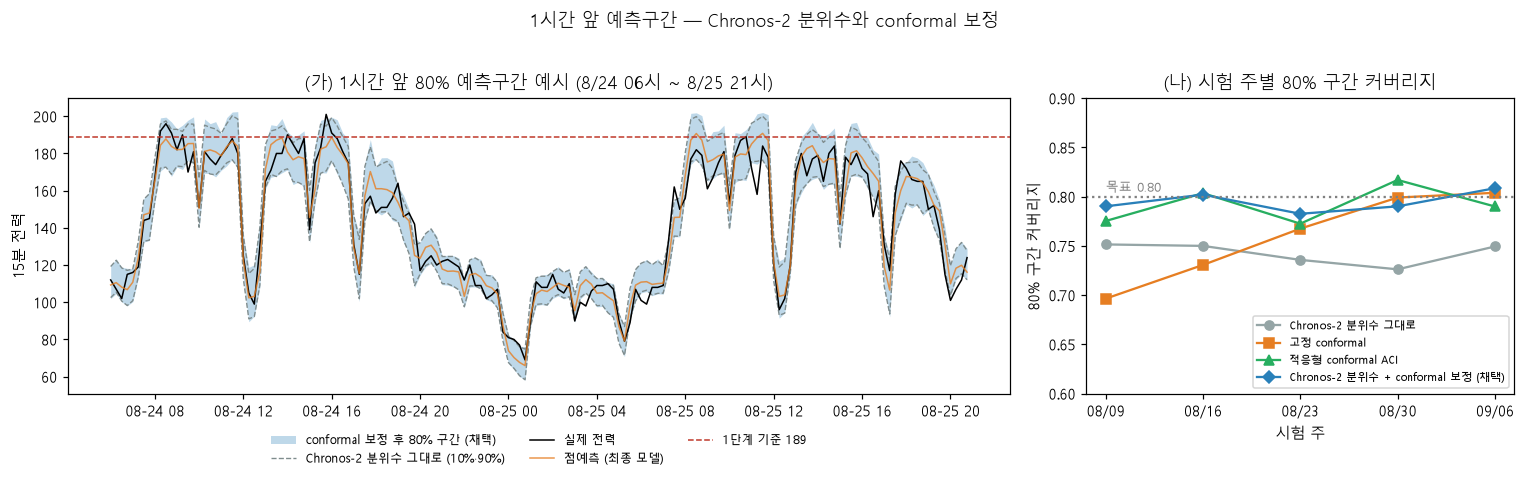

점예측(최종 모델)이 채택한 80% 구간 밖에 놓이는 칸: 1.2%


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3), gridspec_kw={"width_ratios": [2.2, 1]})
ex = ((hq["대상시각"] >= "2021-08-24 06:00") & (hq["대상시각"] < "2021-08-25 21:00")).values   # 매 정시 발행한 4칸을 이어 붙이면 15분마다 하나씩
xx = hq.loc[ex, "대상시각"]
Qc = METHODS["Chronos-2 분위수 + conformal 보정 (채택)"][ex]; Qr = METHODS["Chronos-2 분위수 그대로"][ex]
axes[0].fill_between(xx, Qc[:, I10], Qc[:, I90], color="#2980b9", alpha=0.3, lw=0, label="conformal 보정 후 80% 구간 (채택)")
axes[0].plot(xx, Qr[:, I90], color="#7f8c8d", ls="--", lw=0.9, label="Chronos-2 분위수 그대로 (10%·90%)")
axes[0].plot(xx, Qr[:, I10], color="#7f8c8d", ls="--", lw=0.9)
axes[0].plot(xx, hq.loc[ex, "정답"], color="black", lw=1, label="실제 전력")
axes[0].plot(xx, hq.loc[ex, "최종"], color="#e67e22", lw=1, alpha=0.8, label="점예측 (최종 모델)")
axes[0].axhline(L1, color="#c0392b", ls="--", lw=1, label=f"1단계 기준 {L1:.0f}")
axes[0].set_ylabel("15분 전력"); axes[0].legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
axes[0].set_title("(가) 1시간 앞 80% 예측구간 예시 (8/24 06시 ~ 8/25 21시)")
for name, col, mk in [("Chronos-2 분위수 그대로", "#95a5a6", "o"), ("고정 conformal (최종 예측 + 과거 오차)", "#e67e22", "s"),
                      (f"적응형 conformal ACI (갱신 속도 {GAMMA})", "#27ae60", "^"), ("Chronos-2 분위수 + conformal 보정 (채택)", "#2980b9", "D")]:
    w = weekly[name]; axes[1].plot(w.index, w.values, marker=mk, color=col, label=name.replace(" (최종 예측 + 과거 오차)", "").replace(f" (갱신 속도 {GAMMA})", ""))
axes[1].axhline(0.8, color="gray", ls=":"); axes[1].text(0, 0.805, "목표 0.80", fontsize=8.5, color="gray")
axes[1].set_ylim(0.6, 0.9); axes[1].set_xlabel("시험 주"); axes[1].set_ylabel("80% 구간 커버리지"); axes[1].legend(fontsize=7.5, loc="lower right")
axes[1].set_title("(나) 시험 주별 80% 구간 커버리지")
fig.suptitle("1시간 앞 예측구간 — Chronos-2 분위수와 conformal 보정", y=1.02)
fig.tight_layout(); save_fig(fig, "f25_1시간앞_예측구간"); plt.show()
outside = ((F_ < METHODS["Chronos-2 분위수 + conformal 보정 (채택)"][:, I10]) | (F_ > METHODS["Chronos-2 분위수 + conformal 보정 (채택)"][:, I90]))[test_m].mean()
print(f"점예측(최종 모델)이 채택한 80% 구간 밖에 놓이는 칸: {outside:.1%}")

**해석**
- 구간으로 계산한 확률로 경보해도 **같은 재현율에서 경보 수는 여유값 규칙과 거의 같습니다**(재현율 0.77에서 하루 11.2칸 vs 11.9칸). 재현율 0.90에서는 15.3칸 vs 16.3칸으로 확률 쪽이 조금 적지만, 피크 칸이 60개뿐이라 의미 있는 차이로 보기 어렵습니다. PR-AUC도 비슷합니다(0.181 vs 0.185). 표의 여유값 규칙 11.2칸은 다른 행과 같은 방식(점수 순서로 문턱을 맞춤)으로 계산한 값이며, 여유값 10을 그대로 쓰면 11.3칸(표 20)입니다. 어떤 칸이 위험한지의 순서는 결국 최종 예측값이 정하고, 구간은 그 주위의 폭만 더하기 때문입니다. **경보 성능을 높이려면 규칙이 아니라 예측 자체가 좋아져야 합니다.** 그래서 경보 규칙(여유값 10)은 그대로 둡니다.
- 대신 이 확률은 **크기가 대체로 맞습니다**(채택 방법의 평균 확률 0.033, 실제 초과 비율 0.021). 하루 앞 확률(실제의 약 2배)보다 훨씬 정직합니다. 그래서 담당자에게 "다음 1시간 안에 1단계를 넘을 확률 약 30%"처럼 전할 수 있습니다.
- 여유값 10은 이 확률이 약 15% 이상일 때 경보하는 것과 경보 수가 같습니다. 2-1절의 문턱 1/(1+k)로 바꾸면 **놓친 피크 비용을 헛경보의 약 6배로 보는 것**과 비슷합니다.
- 그림 25(가)처럼 보정 후 구간은 1단계 기준 근처의 칸에서 "최악의 경우 기준을 넘을 수 있다"를 보여 줍니다. 4장의 당일 대응(피크 관리 도우미)에서 예측값과 함께 구간 상한을 보여 주면, 숫자 하나보다 정직한 판단 근거가 됩니다.

## 6. 정리 — 보고서 3장 핵심

**피크 기준 (요금 제도 근거)**
- 목표전력 = 학습 기간 최대 222. 1단계 '주의' = 85%(189), 2단계 '경고' = 90%(200).
- 시험 기간에는 목표전력을 넘은 15분이 없었습니다(최대 218).
- 요금은 경부하·공휴일을 뺀 시간대로 매겨지지만, 목표전력 222는 최대부하 시간대 피크라 어느 기준으로도 같습니다. 08시대는 2021년 기준으로는 경부하, 현행 기준으로는 중간부하입니다(t34).

**예측이 틀리는 조건**
| 조건 | 결과 |
|---|---|
| 가동일 주간 (08~19시) | 오차 대부분이 여기서 생김 (하루 앞 11.5, 1시간 앞 8.9) |
| 평소와 다르게 운영한 날 | 8/16(대체공휴일 가동), 8/17, 8/09(휴무 직후), 8/28(토) |
| 시기에 따른 수준 변화 | 시험 기간 피크가 학습 기간보다 낮아(초과 비율 9.0% → 4.5%), 하루 앞 예측과 확률이 높게 나옴 |
| 월요일 등 전날 휴일인 날 | 오차와 경보 놓침이 더 많음 |

**영향요인**
- **하루 종류 × 시각**: 전력의 기본 모양을 정함 (1장, 2장)
- **시기·운영 수준**: 기간에 따라 피크 수준이 달라짐
- **기온**: 하루 최대와 관련이 있어 보이나(1℃당 약 2~3), 남은 오차에 대한 효과는 95% 범위가 0을 포함해 이 데이터로 확인되지 않음(t36)
- **계획 생산량, 습도, 강수량**: 남은 오차와 뚜렷한 관계 없음

**피크 경보**
| | 하루 앞 | 1시간 앞 |
|---|---|---|
| 역할 | 내일의 위험 시간대 안내 (08시·11시·14시 부근) | 곧 올 피크 경보 |
| 성능 | 시간대는 맞히지만 확률이 높게 나오고, '넘는 날'과 정확한 칸은 못 맞힘 | 피크 칸 77%(95% 범위 58~87%), 피크 사건 72~79% 포착. 사건 39회 중 21회는 45분 이상 전에 경보. F1 0.30 |
| 경보 수 | 문턱 9%면 재현율 0.84, 하루 19칸 | 여유값 10이면 하루 11.3칸. 같은 재현율에서 기준 곡선만 쓸 때보다 약 25~34%, 과거 초과율 규칙보다 약 44% 적음 |
| 약한 곳 (경향, 범위가 겹쳐 단정 불가) | 오후, 서늘한 날 | 오전, 월요일, 15분짜리 짧은 피크 |

**주의 (한계)**
- 하루 단위 기온 분석은 시험 기간의 실제 기온을 썼으므로 '기온 예보가 정확하다면'의 결과입니다.
- 여유값은 1주차로 골랐고, 1주차 목표(재현율 90%)는 2~5주차에서 77%로 떨어졌습니다.
- 시험 기간 피크가 60칸(39회)뿐이라 재현율·정밀도·조건별 비율의 95% 범위가 넓습니다.

**4장(현장 활용)으로 이어질 내용**
- 피크 위험 시간대(평일 08:00~12:00, 13:00~16:00)의 설비 기동을 분산하는 일정 조정
- 1시간 앞 경보가 울리면 할 수 있는 조치 (대용량 설비 기동 미루기 등). 피크 사건 39회 중 21회는 45분 이상 준비 시간이 있었음
- 월요일·휴무 직후 첫날·공휴일 가동일은 주의 수준을 높이는 보조 규칙
- 경보 수와 놓친 피크 사이의 선택 (그림 17의 여유값 곡선)